# Rosenzweig (1981) — Section 1  
*Cost-free, Density-independent Habitat Selection: Mathematics of the Two Codes*

---

## Part 0 — Shared mathematical setup

### 0.1 Phenotype parameterisation

Phenotypes are indexed by a one-dimensional trait

$$
\theta \in \left[0,\ \tfrac{\pi}{2}\right].
$$

The two endpoints are the extreme specialists:

- $\theta = 0$: extreme $B$-specialist,
- $\theta = \pi/2$: extreme $G$-specialist.

Interior $\theta$ are intermediate specialists; the generalist $\theta_F$ satisfies $W_B(\theta_F) = W_G(\theta_F)$.

### 0.2 Patch fitness functions

Both codes use

$$
W_B(\theta) = W_{B0}\cos\theta, \qquad
W_G(\theta) = W_{G0}\sin\theta,
$$

with $W_{B0} = 1.0$ and $W_{G0} = 1.2$. These are the parametric equations of a quarter-ellipse:

$$
\left(\frac{W_B}{W_{B0}}\right)^2 + \left(\frac{W_G}{W_{G0}}\right)^2 = 1,
\qquad W_B, W_G \ge 0.
$$

**Why an ellipse?** The ellipse is the simplest smooth curve connecting $(W_{B0}, 0)$ to $(0, W_{G0})$ with strictly negative slope. Its slope is

$$
\frac{dW_G}{dW_B}
= \frac{W_{G0}\cos\theta\,d\theta}{-W_{B0}\sin\theta\,d\theta}
= -\frac{W_{G0}}{W_{B0}}\cot\theta < 0
$$

for all $\theta \in (0, \pi/2)$, so the tradeoff is strict everywhere. This is the negative-slope frontier of Fig. 1 in the paper.

### 0.3 Generalist phenotype and fitness

Setting $W_B(\theta) = W_G(\theta)$:

$$
W_{B0}\cos\theta_F = W_{G0}\sin\theta_F
\;\Longrightarrow\;
\tan\theta_F = \frac{W_{B0}}{W_{G0}},
$$

so

$$
\theta_F = \arctan\!\frac{W_{B0}}{W_{G0}}.
$$

The generalist fitness is the common value

$$
W_F = W_{B0}\cos\theta_F = W_{G0}\sin\theta_F.
$$

Using $\cos\theta_F = W_{G0}/\sqrt{W_{B0}^2 + W_{G0}^2}$ and $\sin\theta_F = W_{B0}/\sqrt{W_{B0}^2 + W_{G0}^2}$,

$$
W_F = \frac{W_{B0}\,W_{G0}}{\sqrt{W_{B0}^2 + W_{G0}^2}}.
$$

In code: `theta_F = np.arctan(W_B0/W_G0)` and `W_gen = W_B0*W_G0/np.sqrt(W_B0**2 + W_G0**2)`. Numerically $\theta_F \approx 0.6947$, $W_F \approx 0.7682$.

### 0.4 Fitness set (Panels B of both codes)

The fitness set is the region

$$
\mathcal{F} = \{(W_B(\theta), W_G(\theta)) : \theta \in [0, \pi/2]\} \cup \text{(convex hull)},
$$

bounded by the ellipse arc. The code plots the arc, the interior fill, the two extreme points $(W_{B0}, 0)$ and $(0, W_{G0})$, the generalist point $(W_F, W_F)$, and the line $W_G = W_B$ on which all generalists lie. The scaled copies $s\,W_B(\theta), s\,W_G(\theta)$ for $s \in \{0.25, 0.50, 0.75\}$ are homothetic contours of the fitness set.

---

## Part 1 — Mathematics of the fine-grained code

### 1.1 Panel A — Phenotype space & distribution

The code draws two Gaussian bumps

$$
f(\theta) = e^{-\frac12\left(\frac{\theta - 0.20}{0.15}\right)^2}
+ 0.6\,e^{-\frac12\left(\frac{\theta - 1.20}{0.20}\right)^2},
$$

normalised to $f_{\max} = 0.30$ and plotted above a baseline at $0.50$. This is illustrative — a hypothetical bimodal phenotype distribution with peaks near the $B$-specialist side and the $G$-specialist side. Markers at $\theta = 0$, $\theta = \pi/2$, and $\theta_F$.

### 1.2 Panel B — Fitness set

Same as Section 0.4.

### 1.3 Panel C — Fine-grained fitness contours

**Definition.** A fine-grained forager encounters patch $G$ with probability $P_G$ and patch $B$ with probability $1 - P_G$. Its expected fitness is the linear combination

$$
W_{\text{fine}}(\theta; P_G)
= P_G\,W_G(\theta) + (1 - P_G)\,W_B(\theta).
$$

In code: `W_fine(theta, P_G) = P_G*W_G(theta) + (1-P_G)*W_B(theta)`.

**Contours.** Fix a target fitness $c$. The level set in the $(W_B, W_G)$ plane is

$$
P_G\,W_G + (1 - P_G)\,W_B = c
\;\Longleftrightarrow\;
W_G = \frac{c - (1 - P_G)W_B}{P_G},
$$

a straight line of slope

$$
\frac{dW_G}{dW_B} = -\frac{1 - P_G}{P_G}
$$

in the fitness plane. The code draws these lines for $P_G \in \{0.15, 0.35, 0.50, 0.65, 0.85\}$.

**Optimal phenotype.** Maximise $W_{\text{fine}}(\theta; P_G)$ over $\theta$. The first-order condition is

$$
P_G\,W_G'(\theta) + (1 - P_G)\,W_B'(\theta) = 0.
$$

Substituting the derivatives:

$$
P_G\,W_{G0}\cos\theta - (1 - P_G)\,W_{B0}\sin\theta = 0
\;\Longrightarrow\;
\tan\theta^* = \frac{P_G\,W_{G0}}{(1 - P_G)\,W_{B0}}.
$$

So

$$
\theta^*(P_G) = \arctan\!\frac{P_G\,W_{G0}}{(1 - P_G)\,W_{B0}}.
$$

In code: `theta_opt_fine(P_G) = np.arctan2(P_G*W_G0, (1-P_G)*W_B0)`.

### 1.4 Panel D — The U-shaped fitness theorem

**Envelope.** Substitute $\theta^*(P_G)$ into $W_{\text{fine}}$ to get the optimal fitness

$$
V(P_G) = \max_\theta W_{\text{fine}}(\theta; P_G).
$$

**Derivation.** Let $a = P_G W_{G0}$ and $b = (1 - P_G)W_{B0}$. Then

$$
W_{\text{fine}}(\theta) = a\sin\theta + b\cos\theta
= \sqrt{a^2 + b^2}\,\cos(\theta - \phi),
$$

where $\phi = \arctan(a/b) = \theta^*(P_G)$. The maximum over $\theta$ is

$$
V(P_G) = \sqrt{a^2 + b^2}
= \sqrt{(P_G W_{G0})^2 + ((1 - P_G)W_{B0})^2}.
$$

In code: `V_fine(P_G) = np.sqrt((P_G*W_G0)**2 + ((1-P_G)*W_B0)**2)`.

**Why it is convex (U-shaped).** The Euclidean norm $\|\cdot\|_2$ is convex, and $P_G \mapsto (a(P_G), b(P_G))$ is affine in $P_G$. Composition of a convex function with an affine map is convex. Hence $V(P_G)$ is convex — its graph is the U-shape in Fig. 2.

**Minimum.** Differentiate $V^2$ with respect to $P_G$:

$$
\frac{dV^2}{dP_G}
= 2P_G W_{G0}^2 - 2(1 - P_G)W_{B0}^2 = 0
$$

gives

$$
P_G^* = \frac{W_{B0}^2}{W_{B0}^2 + W_{G0}^2}.
$$

At this point $\tan\theta^* = W_{G0}W_{B0}^2/(W_{B0}W_{G0}^2) = W_{B0}/W_{G0} = \tan\theta_F$, so

$$
\theta^*(P_G^*) = \theta_F
$$

— the generalist is exactly optimal at $P_G^*$. The minimum value is $W_F$, which is why the red dashed line in Panel D sits tangent to the U-curve at $P_G^*$.

### 1.5 Panel E — Optimal phenotype vs $P_G$

Plot of

$$
\theta^*(P_G) = \arctan\!\frac{P_G W_{G0}}{(1 - P_G)W_{B0}}
\quad\text{for } P_G \in (0, 1).
$$

Endpoints: $\theta^*(0^+) = 0$, $\theta^*(1^-) = \pi/2$. It is strictly increasing and crosses $\theta_F$ exactly at $P_G = P_G^*$.

### 1.6 Panel F — Fine-grained fitness with the generalist marked

The code plots

$$
\theta \mapsto W_{\text{fine}}(\theta; P_G)
$$

for $P_G \in \{0.20, 0.40, 0.50, 0.60, 0.80\}$. Each is a sinusoid

$$
W_{\text{fine}}(\theta) = a\sin\theta + b\cos\theta,
$$

whose maximum is $V(P_G)$ at $\theta^*(P_G)$. The vertical red line is $\theta_F$; the red star is $(\theta_F, W_F)$. At $P_G = P_G^* \approx 0.410$, the red star is exactly the peak of the $P_G = 0.41$ curve. For any other $P_G$, the star lies below the curve's peak.

### 1.7 Panel G — Population dynamics

**Model.** A Lotka–Volterra competition system with $n = 12$ phenotypes:

$$
\dot N_i = N_i \Bigl[ \underbrace{W_{\text{fine}}(\theta_i; P_G)}_{\text{per-capita growth}}
\Bigl(1 - \tfrac{\sum_j N_j}{K}\Bigr) - \mu \Bigr].
$$

Parameters: $K = 1000$, $\mu = 0.40$, $P_G = 0.50$, $N_i(0) = 5$.

**Interpretation.** Each phenotype has intrinsic growth rate $r_i = W_{\text{fine}}(\theta_i; P_G) - \mu$ and is limited by total population via the factor $(1 - \sum_j N_j/K)$. This is competitive exclusion with a shared carrying capacity.

**Explicit Euler scheme.** The code does

$$
N_i(t + \Delta t) = N_i(t) + \Delta t\,N_i(t)\bigl[W_{\text{fine}}(\theta_i; P_G)(1 - \Sigma/K) - \mu\bigr],
$$

with $\Delta t = 0.05$ and $T = 200$.

**Equilibrium.** The system converges to a single-phenotype equilibrium. The winning phenotype is the one with the largest $W_{\text{fine}}$, i.e. $\theta^*(P_G)$, because it has the highest $r_i$ and hence the largest $R^* = \mu K/(W_i - \mu)$. At $P_G = 0.5$ the optimum is $\theta^* \approx 0.876 \ne \theta_F$, so the generalist loses.

### 1.8 Panel H — Equilibrium distribution

Bar plot of $N_i(T)$. Only the winner is non-zero, at $\theta^*(0.5) \approx 0.876$, with

$$
N^* = K\left(1 - \frac{\mu}{W_i}\right).
$$

### 1.9 Panel I — Zoom near the generalist

Plots $W_B$, $W_G$, and $W_{\text{fine}}(\cdot; P_G)$ for $P_G \in \{0.30, 0.41, 0.50\}$ in $|\theta - \theta_F| < 0.5$. The red star is the generalist. Only the $P_G = 0.41$ curve peaks exactly at the star.

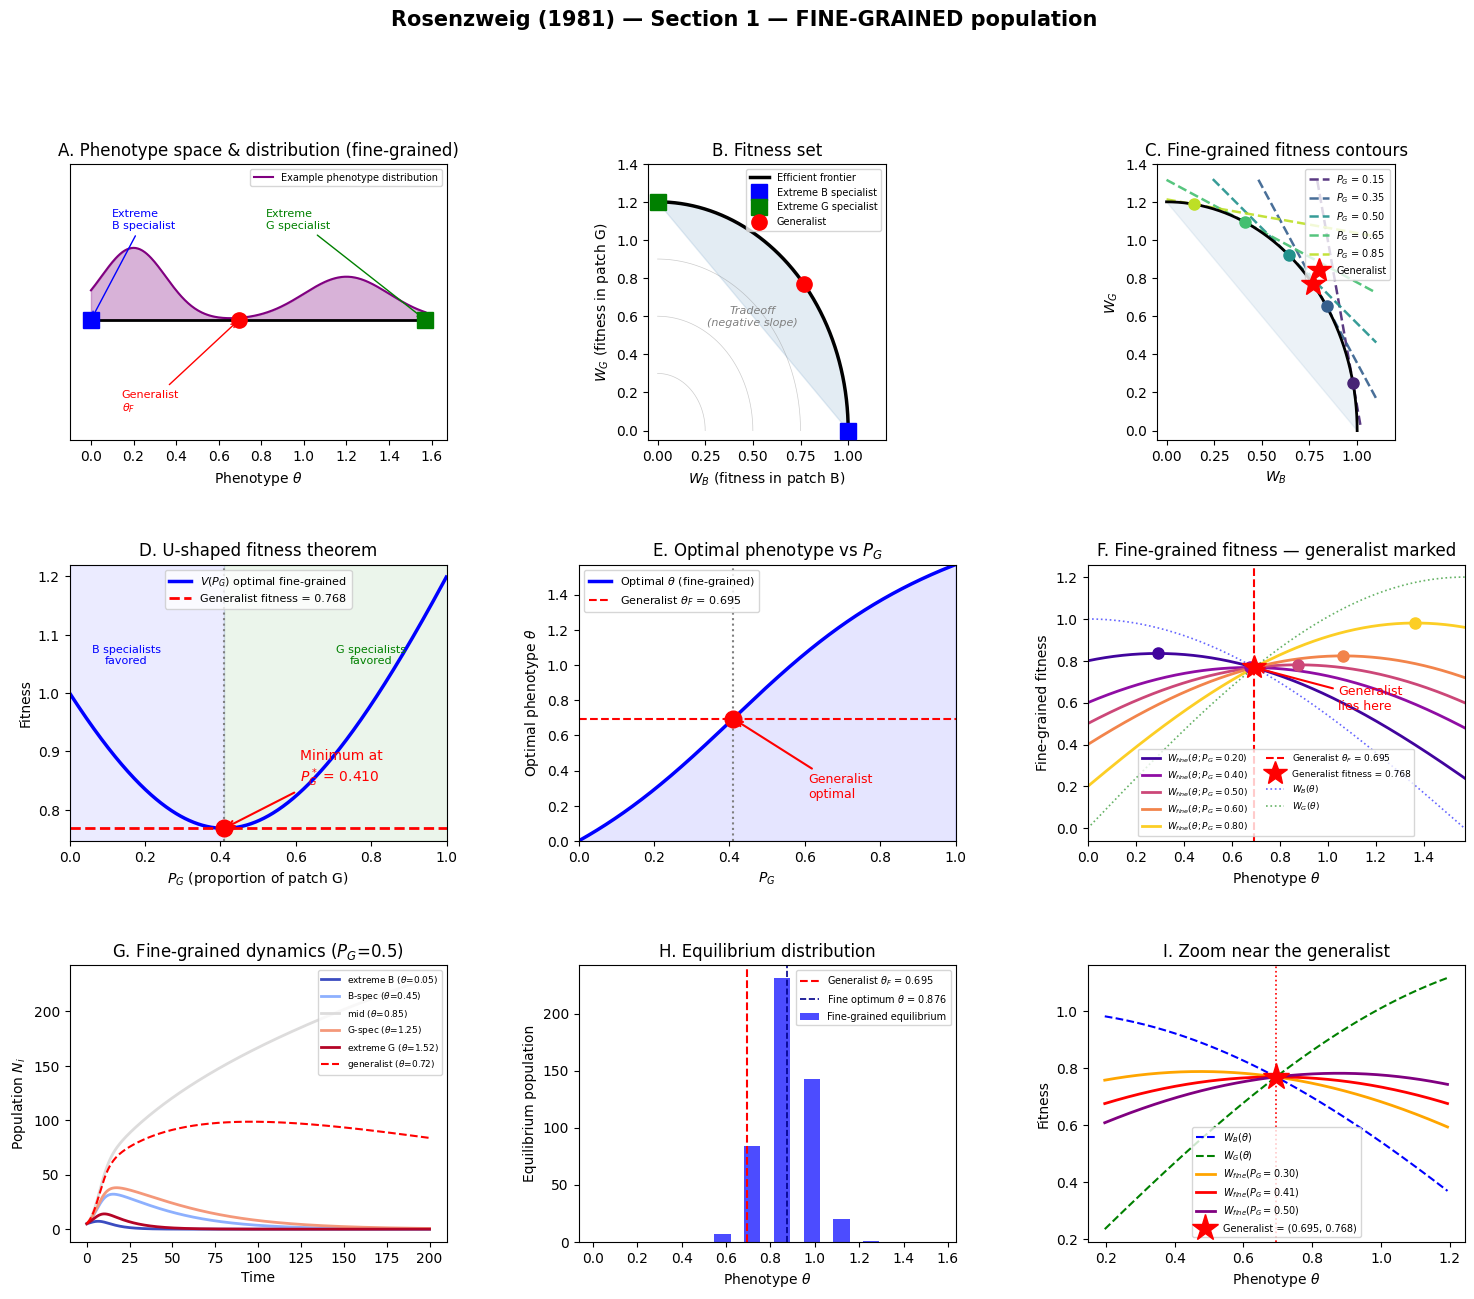

In [3]:
"""
Rosenzweig (1981) — Section 1 — FINE-GRAINED (opportunistic) population
Cost-free, density-independent habitat selection.

Panels:
  A. Phenotype space & example distribution
  B. Fitness set
  C. Fine-grained fitness contours
  D. U-shaped fitness theorem
  E. Optimal phenotype vs P_G
  F. Fine-grained fitness with the generalist marked
  G. Population dynamics (multi-phenotype Lotka-Volterra)
  H. Equilibrium phenotype distribution
  I. Zoom on the generalist region
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ============================================================
# Parameters
# ============================================================
W_B0 = 1.0          # maximum fitness in patch B
W_G0 = 1.2          # maximum fitness in patch G

theta_F  = np.arctan(W_B0 / W_G0)                       # generalist phenotype
P_G_star = W_B0**2 / (W_B0**2 + W_G0**2)                # P_G where generalist is optimal
W_gen    = W_B0 * W_G0 / np.sqrt(W_B0**2 + W_G0**2)     # generalist fitness

# ============================================================
# Fitness functions (fine-grained)
# ============================================================
def W_B(theta):
    return W_B0 * np.cos(theta)

def W_G(theta):
    return W_G0 * np.sin(theta)

def W_fine(theta, P_G):
    """Fine-grained fitness: weighted average by patch encounter."""
    return P_G * W_G(theta) + (1.0 - P_G) * W_B(theta)

def V_fine(P_G):
    """Optimal fine-grained fitness (envelope over theta)."""
    return np.sqrt((P_G * W_G0)**2 + ((1.0 - P_G) * W_B0)**2)

def theta_opt_fine(P_G):
    """Optimal phenotype for a fine-grained population at given P_G."""
    return np.arctan2(P_G * W_G0, (1.0 - P_G) * W_B0)

# ============================================================
# Figure
# ============================================================
fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

theta   = np.linspace(0.0, np.pi/2, 600)
P_G_arr = np.linspace(0.001, 0.999, 600)

# ------------------------------------------------------------
# Panel A — Phenotype space & distribution
# ------------------------------------------------------------
ax_A = fig.add_subplot(gs[0, 0])
theta_dist = np.linspace(0.0, np.pi/2, 300)
dist = (np.exp(-0.5 * ((theta_dist - 0.20) / 0.15)**2)
        + 0.6 * np.exp(-0.5 * ((theta_dist - 1.20) / 0.20)**2))
dist = dist / dist.max() * 0.30

ax_A.fill_between(theta_dist, 0.50, 0.50 + dist, alpha=0.30, color='purple')
ax_A.plot(theta_dist, 0.50 + dist, color='purple', lw=1.5,
          label='Example phenotype distribution')
ax_A.plot(theta, np.full_like(theta, 0.50), 'k-', lw=2)

ax_A.plot(0.0,      0.50, 'bs', ms=11, zorder=5)
ax_A.plot(np.pi/2,  0.50, 'gs', ms=11, zorder=5)
ax_A.plot(theta_F,  0.50, 'ro', ms=11, zorder=5)

ax_A.annotate('Extreme\nB specialist', xy=(0.0, 0.50), xytext=(0.10, 0.88),
              arrowprops=dict(arrowstyle='->', color='blue'), fontsize=8, color='blue')
ax_A.annotate('Extreme\nG specialist', xy=(np.pi/2, 0.50),
              xytext=(np.pi/2 - 0.75, 0.88),
              arrowprops=dict(arrowstyle='->', color='green'), fontsize=8, color='green')
ax_A.annotate('Generalist\n$\\theta_F$', xy=(theta_F, 0.50),
              xytext=(theta_F - 0.55, 0.12),
              arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')

ax_A.set_xlabel('Phenotype $\\theta$')
ax_A.set_yticks([])
ax_A.set_title('A. Phenotype space & distribution (fine-grained)')
ax_A.set_xlim(-0.10, np.pi/2 + 0.10)
ax_A.set_ylim(0.0, 1.15)
ax_A.legend(fontsize=7, loc='upper right')

# ------------------------------------------------------------
# Panel B — Fitness set
# ------------------------------------------------------------
ax_B = fig.add_subplot(gs[0, 1])
ax_B.fill(W_B(theta), W_G(theta), alpha=0.15, color='steelblue')
for s in (0.25, 0.50, 0.75):
    ax_B.plot(s * W_B(theta), s * W_G(theta), 'gray', lw=0.5, alpha=0.40)
ax_B.plot(W_B(theta), W_G(theta), 'k-', lw=2.5, zorder=3,
          label='Efficient frontier')
ax_B.plot(W_B0, 0.0, 'bs', ms=11, zorder=5, label='Extreme B specialist')
ax_B.plot(0.0, W_G0, 'gs', ms=11, zorder=5, label='Extreme G specialist')
ax_B.plot(W_B(theta_F), W_G(theta_F), 'ro', ms=11, zorder=5, label='Generalist')
ax_B.annotate('Tradeoff\n(negative slope)', xy=(0.50, 0.55),
              fontsize=8, ha='center', color='gray', style='italic')
ax_B.set_xlabel('$W_B$ (fitness in patch B)')
ax_B.set_ylabel('$W_G$ (fitness in patch G)')
ax_B.set_title('B. Fitness set')
ax_B.legend(fontsize=7, loc='upper right')
ax_B.set_aspect('equal')
ax_B.set_xlim(-0.05, 1.20)
ax_B.set_ylim(-0.05, 1.40)

# ------------------------------------------------------------
# Panel C — Fine-grained fitness contours
# ------------------------------------------------------------
ax_C = fig.add_subplot(gs[0, 2])
ax_C.fill(W_B(theta), W_G(theta), alpha=0.10, color='steelblue')
ax_C.plot(W_B(theta), W_G(theta), 'k-', lw=2, zorder=3)

P_G_contours = [0.15, 0.35, 0.50, 0.65, 0.85]
colors_C = plt.cm.viridis(np.linspace(0.10, 0.90, len(P_G_contours)))

for P_G, c in zip(P_G_contours, colors_C):
    th_o  = theta_opt_fine(P_G)
    const = P_G * W_G(th_o) + (1.0 - P_G) * W_B(th_o)
    W_B_ln = np.linspace(0.0, W_B0 * 1.1, 300)
    W_G_ln = (const - (1.0 - P_G) * W_B_ln) / P_G
    mask = ((W_G_ln >= 0.0) & (W_G_ln <= W_G0 * 1.1)
            & (W_B_ln >= 0.0) & (W_B_ln <= W_B0 * 1.1))
    ax_C.plot(W_B_ln[mask], W_G_ln[mask], '--', color=c, lw=1.8, alpha=0.9,
              label=f'$P_G$ = {P_G:.2f}')
    ax_C.plot(W_B(th_o), W_G(th_o), 'o', color=c, ms=8, zorder=5)

ax_C.plot(W_B(theta_F), W_G(theta_F), 'r*', ms=18, zorder=6, label='Generalist')
ax_C.set_xlabel('$W_B$')
ax_C.set_ylabel('$W_G$')
ax_C.set_title('C. Fine-grained fitness contours')
ax_C.legend(fontsize=7, loc='upper right')
ax_C.set_aspect('equal')
ax_C.set_xlim(-0.05, 1.20)
ax_C.set_ylim(-0.05, 1.40)

# ------------------------------------------------------------
# Panel D — U-shaped fitness theorem
# ------------------------------------------------------------
ax_D = fig.add_subplot(gs[1, 0])
V_arr = V_fine(P_G_arr)
ax_D.plot(P_G_arr, V_arr, 'b-', lw=2.5, label='$V(P_G)$ optimal fine-grained')
ax_D.axhline(W_gen, color='red', ls='--', lw=2,
             label=f'Generalist fitness = {W_gen:.3f}')
ax_D.axvline(P_G_star, color='gray', ls=':', lw=1.5)
ax_D.plot(P_G_star, W_gen, 'ro', ms=12, zorder=5)
ax_D.annotate(f'Minimum at\n$P_G^*$ = {P_G_star:.3f}',
              xy=(P_G_star, W_gen),
              xytext=(P_G_star + 0.20, W_gen + 0.08),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
              fontsize=10, color='red')
ax_D.axvspan(0.0, P_G_star, alpha=0.08, color='blue')
ax_D.axvspan(P_G_star, 1.0, alpha=0.08, color='green')
ax_D.text(0.15, 1.05, 'B specialists\nfavored', ha='center', fontsize=8, color='blue')
ax_D.text(0.80, 1.05, 'G specialists\nfavored', ha='center', fontsize=8, color='green')
ax_D.set_xlabel('$P_G$ (proportion of patch G)')
ax_D.set_ylabel('Fitness')
ax_D.set_title('D. U-shaped fitness theorem')
ax_D.legend(fontsize=8, loc='upper center')
ax_D.set_xlim(0.0, 1.0)

# ------------------------------------------------------------
# Panel E — Optimal phenotype vs P_G
# ------------------------------------------------------------
ax_E = fig.add_subplot(gs[1, 1])
theta_opt_arr = theta_opt_fine(P_G_arr)
ax_E.plot(P_G_arr, theta_opt_arr, 'b-', lw=2.5, label='Optimal $\\theta$ (fine-grained)')
ax_E.axhline(theta_F, color='red', ls='--', lw=1.5,
             label=f'Generalist $\\theta_F$ = {theta_F:.3f}')
ax_E.axvline(P_G_star, color='gray', ls=':', lw=1.5)
ax_E.plot(P_G_star, theta_F, 'ro', ms=12, zorder=5)
ax_E.fill_between(P_G_arr, 0.0, theta_opt_arr, alpha=0.10, color='blue')
ax_E.annotate('Generalist\noptimal', xy=(P_G_star, theta_F),
              xytext=(P_G_star + 0.20, theta_F - 0.45),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
              fontsize=9, color='red')
ax_E.set_xlabel('$P_G$')
ax_E.set_ylabel('Optimal phenotype $\\theta$')
ax_E.set_title('E. Optimal phenotype vs $P_G$')
ax_E.legend(fontsize=8)
ax_E.set_xlim(0.0, 1.0)
ax_E.set_ylim(0.0, np.pi/2)

# ------------------------------------------------------------
# Panel F — Fine-grained fitness with GENERALIST marked
# ------------------------------------------------------------
ax_F = fig.add_subplot(gs[1, 2])

# Plot fine-grained fitness curves for several P_G values
P_G_show = [0.20, 0.40, 0.50, 0.60, 0.80]
colors_F = plt.cm.plasma(np.linspace(0.10, 0.90, len(P_G_show)))

for P_G, c in zip(P_G_show, colors_F):
    ax_F.plot(theta, W_fine(theta, P_G), color=c, lw=2.0,
              label=f'$W_{{fine}}(\\theta; P_G={P_G:.2f})$')
    th_o = theta_opt_fine(P_G)
    ax_F.plot(th_o, W_fine(th_o, P_G), 'o', color=c, ms=8, zorder=5)

# Generalist markers
ax_F.axvline(theta_F, color='red', ls='--', lw=1.5,
             label=f'Generalist $\\theta_F$ = {theta_F:.3f}')
ax_F.plot(theta_F, W_gen, 'r*', ms=18, zorder=6,
          label=f'Generalist fitness = {W_gen:.3f}')

# Also plot W_B and W_G for reference
ax_F.plot(theta, W_B(theta), 'b:', lw=1.2, alpha=0.6, label='$W_B(\\theta)$')
ax_F.plot(theta, W_G(theta), 'g:', lw=1.2, alpha=0.6, label='$W_G(\\theta)$')

# Highlight the generalist region
ax_F.annotate('Generalist\nlies here', xy=(theta_F, W_gen),
              xytext=(theta_F + 0.35, W_gen - 0.20),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
              fontsize=9, color='red')

ax_F.set_xlabel('Phenotype $\\theta$')
ax_F.set_ylabel('Fine-grained fitness')
ax_F.set_title('F. Fine-grained fitness — generalist marked')
ax_F.legend(fontsize=6.5, loc='lower center', ncol=2)
ax_F.set_xlim(0.0, np.pi/2)

# ------------------------------------------------------------
# Panel G — Population dynamics
# ------------------------------------------------------------
def simulate_competition(thetas_sim, W_func, K=1000.0, mu=0.40, T=200.0, dt=0.05):
    N = np.full(len(thetas_sim), 5.0)
    t_arr = np.arange(0.0, T, dt)
    N_hist = [N.copy()]
    for _ in t_arr:
        total  = np.sum(N)
        W_vals = W_func(thetas_sim)
        dN     = N * (W_vals * (1.0 - total / K) - mu)
        N      = np.maximum(N + dN * dt, 0.0)
        N_hist.append(N.copy())
    return np.array(N_hist), np.concatenate([[0.0], t_arr + dt])

thetas_sim = np.linspace(0.05, np.pi/2 - 0.05, 12)
P_G_sim    = 0.50

ax_G = fig.add_subplot(gs[2, 0])
N_hist_fine, t_sim = simulate_competition(thetas_sim,
                                          lambda th: W_fine(th, P_G_sim))
rep_idx    = [0, 3, 6, 9, 11]
rep_labels = ['extreme B', 'B-spec', 'mid', 'G-spec', 'extreme G']
rep_colors = plt.cm.coolwarm(np.linspace(0.0, 1.0, len(rep_idx)))

for idx, lab, col in zip(rep_idx, rep_labels, rep_colors):
    ax_G.plot(t_sim, N_hist_fine[:, idx], color=col, lw=2.0,
              label=f'{lab} ($\\theta$={thetas_sim[idx]:.2f})')

# Mark the generalist
th_gen_idx = np.argmin(np.abs(thetas_sim - theta_F))
ax_G.plot(t_sim, N_hist_fine[:, th_gen_idx], 'r--', lw=1.5,
          label=f'generalist ($\\theta$={thetas_sim[th_gen_idx]:.2f})')

ax_G.set_xlabel('Time')
ax_G.set_ylabel('Population $N_i$')
ax_G.set_title(f'G. Fine-grained dynamics ($P_G$={P_G_sim})')
ax_G.legend(fontsize=6.5, loc='upper right')

# ------------------------------------------------------------
# Panel H — Equilibrium phenotype distribution
# ------------------------------------------------------------
ax_H = fig.add_subplot(gs[2, 1])
N_final = N_hist_fine[-1]
width = 0.55 * (thetas_sim[1] - thetas_sim[0])
ax_H.bar(thetas_sim, N_final, width=width, color='blue', alpha=0.7,
         label='Fine-grained equilibrium')
ax_H.axvline(theta_F, color='red', ls='--', lw=1.5,
             label=f'Generalist $\\theta_F$ = {theta_F:.3f}')
th_opt = theta_opt_fine(P_G_sim)
ax_H.axvline(th_opt, color='darkblue', ls='--', lw=1.2,
             label=f'Fine optimum $\\theta$ = {th_opt:.3f}')
ax_H.set_xlabel('Phenotype $\\theta$')
ax_H.set_ylabel('Equilibrium population')
ax_H.set_title('H. Equilibrium distribution')
ax_H.legend(fontsize=7)

# ------------------------------------------------------------
# Panel I — Zoom on the generalist region
# ------------------------------------------------------------
ax_I = fig.add_subplot(gs[2, 2])
zoom = np.abs(theta - theta_F) < 0.5
ax_I.plot(theta[zoom], W_B(theta[zoom]), 'b--', lw=1.5, label='$W_B(\\theta)$')
ax_I.plot(theta[zoom], W_G(theta[zoom]), 'g--', lw=1.5, label='$W_G(\\theta)$')
for P_G, c in zip([0.30, 0.41, 0.50], ['orange', 'red', 'purple']):
    ax_I.plot(theta[zoom], W_fine(theta[zoom], P_G), color=c, lw=2.0,
              label=f'$W_{{fine}}(P_G={P_G:.2f})$')
ax_I.plot(theta_F, W_gen, 'r*', ms=20, zorder=6,
          label=f'Generalist = ({theta_F:.3f}, {W_gen:.3f})')
ax_I.axvline(theta_F, color='red', ls=':', lw=1.2)
ax_I.set_xlabel('Phenotype $\\theta$')
ax_I.set_ylabel('Fitness')
ax_I.set_title('I. Zoom near the generalist')
ax_I.legend(fontsize=7, loc='lower center')

# ============================================================
plt.suptitle('Rosenzweig (1981) — Section 1 — FINE-GRAINED population',
             fontsize=15, fontweight='bold', y=0.99)

plt.savefig('rosenzweig_fine_grained.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 1 · Coarse-Grained Population — Mathematics Behind the Code
*Cost-free, density-independent habitat selection with geometric-mean fitness contours*

---

## Setup — Variables and phenotype space

The environment contains two usable patch types, $B$ and $G$, embedded in a matrix of unusable space. A phenotype is indexed by a single trait

$$
\theta\in\left[0,\ \frac{\pi}{2}\right],
$$

with the two endpoints corresponding to the extreme specialists:

| Phenotype | $\theta$ | Interpretation |
|---|---|---|
| Extreme $B$ specialist | $0$ | Maximises $W_B$; zero $W_G$ |
| Generalist $\theta_F$ | $\arctan(W_{B0}/W_{G0})$ | Equal fitness in both patches |
| Extreme $G$ specialist | $\pi/2$ | Maximises $W_G$; zero $W_B$ |

- $W_{B0}$ — Maximum achievable fitness in patch $B$. Code uses $1.0$.
- $W_{G0}$ — Maximum achievable fitness in patch $G$. Code uses $1.2$.
- $W_B(\theta)$ — Fitness of phenotype $\theta$ in patch $B$.
- $W_G(\theta)$ — Fitness of phenotype $\theta$ in patch $G$.
- $p_B, p_G$ — Behavioural weights: fraction of time/encounters allocated to each patch, $p_B+p_G=1$.
- $\bar W$ — Overall fitness of the phenotype given its behaviour.
- $c$ — Contour level: $\bar W=c$.

---

## Tradeoff — Patch fitness and the tradeoff

The code uses the simplest smooth tradeoff — a quarter-ellipse:

$$
W_B(\theta)=W_{B0}\cos\theta,\qquad
W_G(\theta)=W_{G0}\sin\theta.
$$

These are the parametric equations of an ellipse arc in $(W_B,W_G)$ space:

$$
\left(\frac{W_B}{W_{B0}}\right)^2+\left(\frac{W_G}{W_{G0}}\right)^2=1,
\qquad W_B,W_G\ge 0.
$$

### Negative slope

The slope of the frontier is

$$
\frac{dW_G}{dW_B}
=\frac{W_{G0}\cos\theta\,d\theta}{-W_{B0}\sin\theta\,d\theta}
=-\frac{W_{G0}}{W_{B0}}\cot\theta<0
\quad\forall\,\theta\in(0,\pi/2).
$$

Strictly negative slope means a **tradeoff**: improving fitness in one patch necessarily reduces fitness in the other. This is Rosenzweig's assumption.

---

## Generalist — The generalist phenotype

Setting $W_B(\theta)=W_G(\theta)$:

$$
W_{B0}\cos\theta_F=W_{G0}\sin\theta_F
\;\Longrightarrow\;
\tan\theta_F=\frac{W_{B0}}{W_{G0}},
$$

$$
\theta_F=\arctan\!\frac{W_{B0}}{W_{G0}}.
$$

Its common fitness in either patch is

$$
W_F=W_B(\theta_F)=W_G(\theta_F)=\frac{W_{B0}\,W_{G0}}{\sqrt{W_{B0}^2+W_{G0}^2}}.
$$

With $W_{B0}=1.0$, $W_{G0}=1.2$: $\theta_F\approx 0.6947$, $W_F\approx 0.7682$. Every generalist lies on the line $W_G=W_B$ of slope 1 through the origin.

---

## Fitness set — The fitness set

The fitness set is the region

$$
\mathcal{F}
=\bigl\{(W_B(\theta),\,W_G(\theta)):\theta\in[0,\pi/2]\bigr\}
\ \cup\ \text{convex hull}.
$$

Its boundary is the ellipse arc from $(W_{B0},0)$ to $(0,W_{G0})$. The three landmarks:

| Point | $(W_B,W_G)$ | Role |
|---|---|---|
| Extreme $B$ | $(W_{B0},0)=(1.0,0)$ | Best in $B$, worst in $G$ |
| Generalist | $(W_F,W_F)=(0.768,0.768)$ | Equal in both |
| Extreme $G$ | $(0,W_{G0})=(0,1.2)$ | Best in $G$, worst in $B$ |

---

## Eq. 1a — Geometric-mean fitness

> **Corrected form.** The correct fitness contour form is the **geometric mean / Cobb–Douglas**:
> $$
> \bar W=W_B^{\,p_B}\,W_G^{\,p_G},\qquad p_B+p_G=1.
> $$
> The L-shaped contour of $\max(W_B,W_G)$ is the limiting case $p_G\to 1$ or $p_G\to 0$; it is *not* the general form.

### Derivation from Rosenzweig Eq. 1a

Rosenzweig's Eq. 1a in log space is

$$
\ln\bar W
=\frac{t_B\ln W_B+t_x\ln W_G+t_m\ln Z}{t_B+t_x+t_m}.
$$

Ignoring the search cost for now ($t_m=0$), and defining the behavioural weights

$$
p_B=\frac{t_B}{t_B+t_x},\qquad
p_G=\frac{t_x}{t_B+t_x},\qquad
p_B+p_G=1,
$$

we obtain

$$
\ln\bar W=p_B\ln W_B+p_G\ln W_G
\;\Longleftrightarrow\;
\bar W=W_B^{\,p_B}\,W_G^{\,p_G}.
$$

In code:

```python
def W_geom(theta, p_G):
    return (W_B(theta))**(1.0 - p_G) * (W_G(theta))**(p_G)

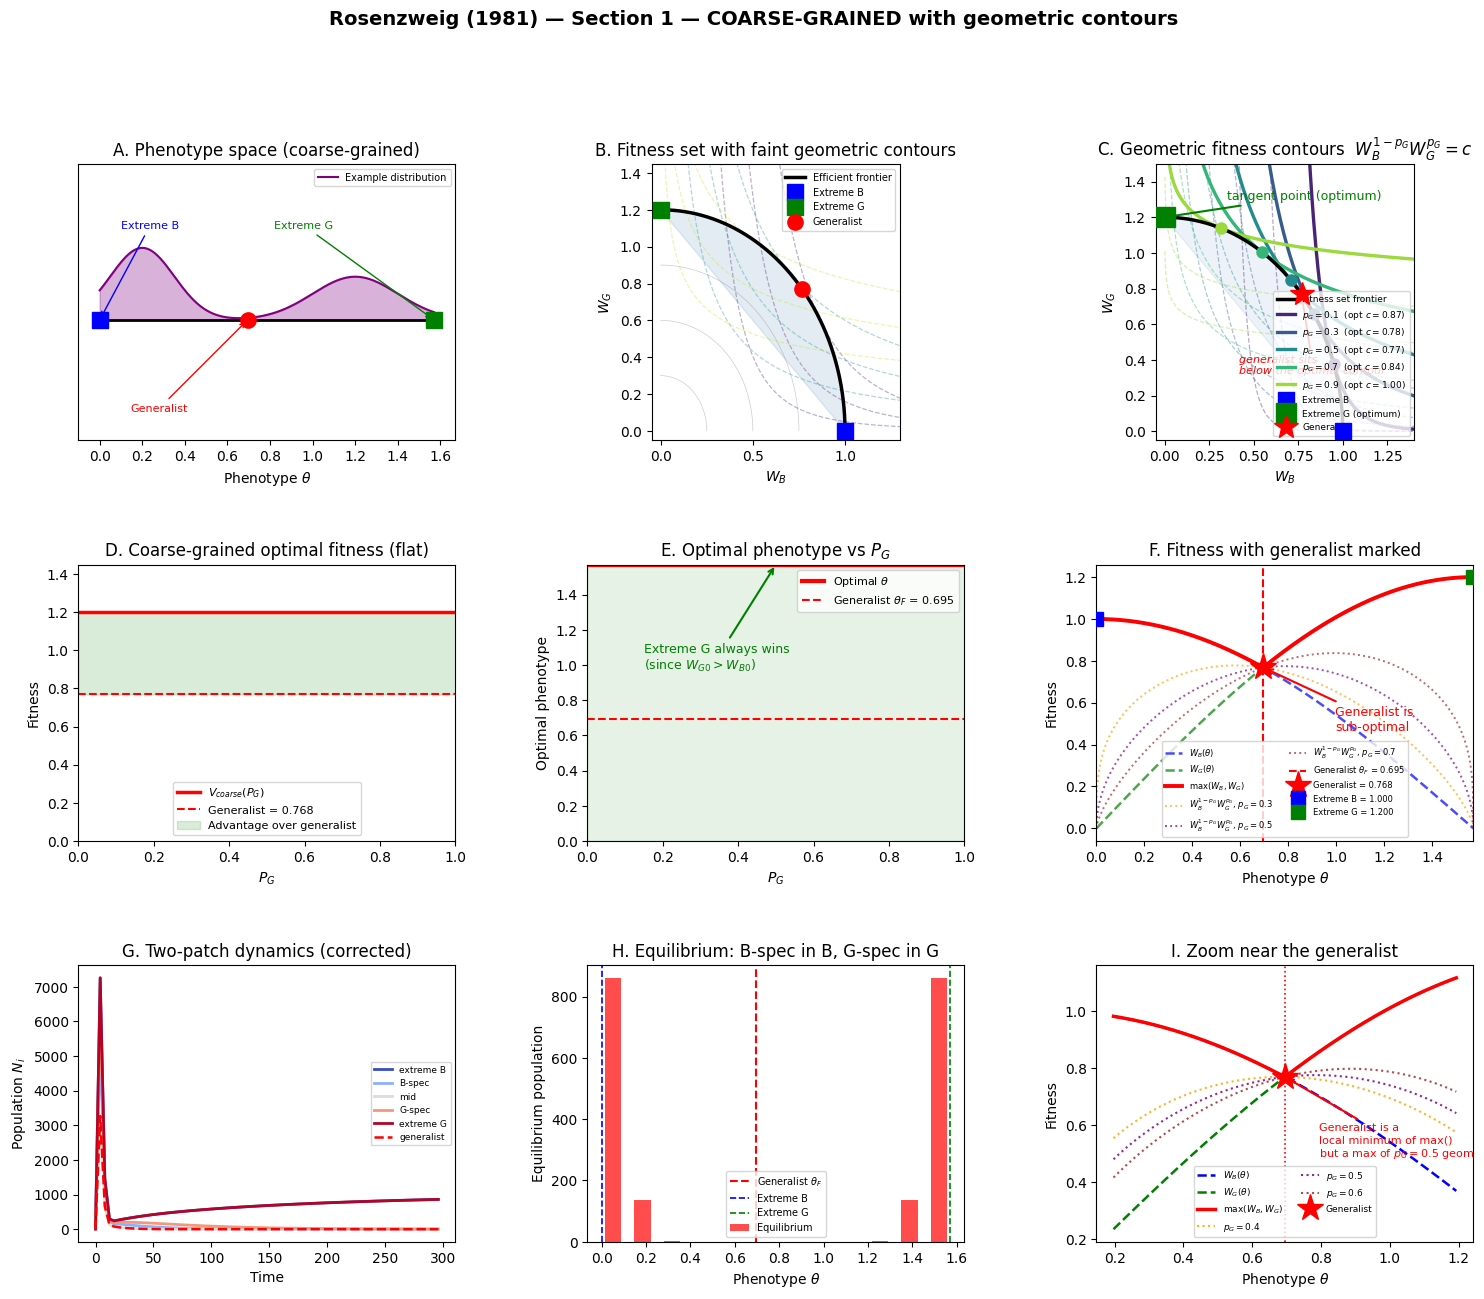

In [4]:
"""
Rosenzweig (1981) — Section 1 — COARSE-GRAINED population
with GEOMETRIC fitness contours  W = W_B^{p_B} * W_G^{p_G}.

Panels:
  A. Phenotype space & distribution
  B. Fitness set with faint geometric contours
  C. Geometric fitness contours (Cobb-Douglas family)
  D. Coarse-grained optimal fitness vs P_G
  E. Optimal phenotype vs P_G
  F. Coarse-grained fitness with the GENERALIST marked
  G. Two-patch dynamics (corrected competition)
  H. Equilibrium phenotype distribution
  I. Zoom near the generalist
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ============================================================
# Parameters
# ============================================================
W_B0, W_G0 = 1.0, 1.2
theta_F  = np.arctan(W_B0 / W_G0)
W_gen    = W_B0 * W_G0 / np.sqrt(W_B0**2 + W_G0**2)

# ============================================================
# Fitness functions
# ============================================================
def W_B(theta): return W_B0 * np.cos(theta)
def W_G(theta): return W_G0 * np.sin(theta)
def W_coarse(theta): return np.maximum(W_B(theta), W_G(theta))

def V_coarse(P_G): return np.maximum(W_B0, W_G0) * np.ones_like(P_G)
def theta_opt_coarse(P_G):
    return np.where(W_G0 > W_B0, np.pi/2, 0.0) * np.ones_like(P_G)

# ------------------------------------------------------------
# Geometric-mean fitness and contour helpers
# ------------------------------------------------------------
def W_geom(theta, p_G):
    """W = W_B^{1-p_G} * W_G^{p_G}  (geometric mean / Cobb-Douglas)."""
    return (W_B(theta))**(1.0 - p_G) * (W_G(theta))**(p_G)

def theta_opt_geom(p_G):
    """Tangency angle: tan(theta*) = sqrt(p_G/(1-p_G))."""
    if p_G <= 0.0:
        return 0.0
    if p_G >= 1.0:
        return np.pi / 2.0
    return np.arctan(np.sqrt(p_G / (1.0 - p_G)))

def contour_geom(p_G, c, W_B_arr):
    """Return W_G(W_B) for the contour  W_B^{1-p_G} W_G^{p_G} = c."""
    eps = 1e-12
    W_B_safe = np.clip(W_B_arr, eps, None)
    if p_G <= 0.0:
        return np.full_like(W_B_safe, np.nan)
    if p_G >= 1.0:
        return np.full_like(W_B_safe, c)
    return (c / W_B_safe**(1.0 - p_G))**(1.0 / p_G)

# ============================================================
# Figure
# ============================================================
fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

theta   = np.linspace(0.0, np.pi/2, 800)
P_G_arr = np.linspace(0.0, 1.0, 600)
W_B_lin = np.linspace(1e-6, 1.4, 600)

# ------------------------------------------------------------
# Panel A — Phenotype space
# ------------------------------------------------------------
ax_A = fig.add_subplot(gs[0, 0])
theta_dist = np.linspace(0.0, np.pi/2, 300)
dist = (np.exp(-0.5 * ((theta_dist - 0.20) / 0.15)**2)
        + 0.6 * np.exp(-0.5 * ((theta_dist - 1.20) / 0.20)**2))
dist = dist / dist.max() * 0.30
ax_A.fill_between(theta_dist, 0.50, 0.50 + dist, alpha=0.30, color='purple')
ax_A.plot(theta_dist, 0.50 + dist, color='purple', lw=1.5,
          label='Example distribution')
ax_A.plot(theta, np.full_like(theta, 0.50), 'k-', lw=2)
ax_A.plot(0.0,     0.50, 'bs', ms=11, zorder=5)
ax_A.plot(np.pi/2, 0.50, 'gs', ms=11, zorder=5)
ax_A.plot(theta_F, 0.50, 'ro', ms=11, zorder=5)
ax_A.annotate('Extreme B', xy=(0.0, 0.50), xytext=(0.10, 0.88),
              arrowprops=dict(arrowstyle='->', color='blue'),
              fontsize=8, color='blue')
ax_A.annotate('Extreme G', xy=(np.pi/2, 0.50), xytext=(np.pi/2 - 0.75, 0.88),
              arrowprops=dict(arrowstyle='->', color='green'),
              fontsize=8, color='green')
ax_A.annotate('Generalist', xy=(theta_F, 0.50), xytext=(theta_F - 0.55, 0.12),
              arrowprops=dict(arrowstyle='->', color='red'),
              fontsize=8, color='red')
ax_A.set_xlabel('Phenotype $\\theta$')
ax_A.set_yticks([])
ax_A.set_title('A. Phenotype space (coarse-grained)')
ax_A.set_xlim(-0.10, np.pi/2 + 0.10)
ax_A.set_ylim(0.0, 1.15)
ax_A.legend(fontsize=7, loc='upper right')

# ------------------------------------------------------------
# Panel B — Fitness set with faint geometric contours
# ------------------------------------------------------------
ax_B = fig.add_subplot(gs[0, 1])
ax_B.fill(W_B(theta), W_G(theta), alpha=0.15, color='steelblue')
for s in (0.25, 0.50, 0.75):
    ax_B.plot(s * W_B(theta), s * W_G(theta), 'gray', lw=0.5, alpha=0.40)
ax_B.plot(W_B(theta), W_G(theta), 'k-', lw=2.5, zorder=3,
          label='Efficient frontier')

# Faint geometric contours for a few p_G
p_G_faint = [0.25, 0.50, 0.75]
for p_G in p_G_faint:
    th_star = theta_opt_geom(p_G)
    c_star  = W_geom(th_star, p_G)
    for frac in (0.6, 0.8, 1.0):
        c = frac * c_star
        W_G_c = contour_geom(p_G, c, W_B_lin)
        mask = (W_G_c <= 1.6)
        ax_B.plot(W_B_lin[mask], W_G_c[mask], '--', lw=0.9, alpha=0.35,
                  color=plt.cm.viridis((p_G - 0.2) / 0.6))

ax_B.plot(W_B0, 0.0, 'bs', ms=11, zorder=5, label='Extreme B')
ax_B.plot(0.0, W_G0, 'gs', ms=11, zorder=5, label='Extreme G')
ax_B.plot(W_B(theta_F), W_G(theta_F), 'ro', ms=11, zorder=5, label='Generalist')

ax_B.set_xlabel('$W_B$')
ax_B.set_ylabel('$W_G$')
ax_B.set_title('B. Fitness set with faint geometric contours')
ax_B.legend(fontsize=7, loc='upper right')
ax_B.set_aspect('equal')
ax_B.set_xlim(-0.05, 1.30)
ax_B.set_ylim(-0.05, 1.45)

# ------------------------------------------------------------
# Panel C — GEOMETRIC fitness contours (Cobb-Douglas family)
# ------------------------------------------------------------
ax_C = fig.add_subplot(gs[0, 2])

# Fitness set background
ax_C.fill(W_B(theta), W_G(theta), alpha=0.10, color='steelblue')
ax_C.plot(W_B(theta), W_G(theta), 'k-', lw=2.5, zorder=3,
          label='Fitness set frontier')

# A family of p_G values
p_G_list = [0.10, 0.30, 0.50, 0.70, 0.90]
colors_C = plt.cm.viridis(np.linspace(0.10, 0.85, len(p_G_list)))

for p_G, col in zip(p_G_list, colors_C):
    # Optimal (tangent) contour
    th_star = theta_opt_geom(p_G)
    c_star  = W_geom(th_star, p_G)
    W_G_c = contour_geom(p_G, c_star, W_B_lin)
    mask = (W_G_c <= 1.6) & (W_G_c >= 0.0)
    ax_C.plot(W_B_lin[mask], W_G_c[mask], '-', color=col, lw=2.4,
              label=f'$p_G={p_G:.1f}$  (opt $c={c_star:.2f}$)')
    # Tangent point
    ax_C.plot(W_B(th_star), W_G(th_star), 'o', color=col, ms=8, zorder=5)

    # A couple of sub-optimal contours (lighter dashed)
    for frac in (0.55, 0.75):
        c_sub = frac * c_star
        W_G_sub = contour_geom(p_G, c_sub, W_B_lin)
        m_sub = (W_G_sub <= 1.6) & (W_G_sub >= 0.0)
        ax_C.plot(W_B_lin[m_sub], W_G_sub[m_sub], '--', color=col,
                  lw=0.9, alpha=0.40)

# Special points
ax_C.plot(W_B0, 0.0, 'bs', ms=12, zorder=6, label='Extreme B')
ax_C.plot(0.0, W_G0, 'gs', ms=14, zorder=7, label='Extreme G (optimum)')
ax_C.plot(W_B(theta_F), W_G(theta_F), 'r*', ms=18, zorder=7,
          label='Generalist')

ax_C.annotate('tangent point (optimum)',
              xy=(0.0, W_G0), xytext=(0.35, W_G0 + 0.10),
              arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
              fontsize=9, color='green')
ax_C.annotate('generalist sits\nbelow the optimal contour',
              xy=(W_B(theta_F), W_G(theta_F)), xytext=(0.42, 0.32),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
              fontsize=8, color='red', style='italic')

ax_C.set_xlabel('$W_B$')
ax_C.set_ylabel('$W_G$')
ax_C.set_title('C. Geometric fitness contours  $W_B^{1-p_G}W_G^{p_G}=c$')
ax_C.legend(fontsize=6.5, loc='lower right')
ax_C.set_aspect('equal')
ax_C.set_xlim(-0.05, 1.40)
ax_C.set_ylim(-0.05, 1.50)

# ------------------------------------------------------------
# Panel D — Coarse-grained optimal fitness vs P_G
# ------------------------------------------------------------
ax_D = fig.add_subplot(gs[1, 0])
V_arr = V_coarse(P_G_arr)
ax_D.plot(P_G_arr, V_arr, 'r-', lw=2.5, label='$V_{coarse}(P_G)$')
ax_D.axhline(W_gen, color='red', ls='--', lw=1.5,
             label=f'Generalist = {W_gen:.3f}')
ax_D.fill_between(P_G_arr, W_gen, V_arr, alpha=0.15, color='green',
                  label='Advantage over generalist')
ax_D.set_xlabel('$P_G$')
ax_D.set_ylabel('Fitness')
ax_D.set_title('D. Coarse-grained optimal fitness (flat)')
ax_D.legend(fontsize=8, loc='lower center')
ax_D.set_xlim(0.0, 1.0)
ax_D.set_ylim(0.0, 1.45)

# ------------------------------------------------------------
# Panel E — Optimal phenotype vs P_G
# ------------------------------------------------------------
ax_E = fig.add_subplot(gs[1, 1])
theta_opt_arr = theta_opt_coarse(P_G_arr)
ax_E.plot(P_G_arr, theta_opt_arr, 'r-', lw=3.0, label='Optimal $\\theta$')
ax_E.axhline(theta_F, color='red', ls='--', lw=1.5,
             label=f'Generalist $\\theta_F$ = {theta_F:.3f}')
ax_E.fill_between(P_G_arr, 0.0, theta_opt_arr, alpha=0.10, color='green')
ax_E.annotate('Extreme G always wins\n(since $W_{G0}>W_{B0}$)',
              xy=(0.5, np.pi/2), xytext=(0.15, np.pi/2 - 0.60),
              arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
              fontsize=9, color='green')
ax_E.set_xlabel('$P_G$')
ax_E.set_ylabel('Optimal phenotype')
ax_E.set_title('E. Optimal phenotype vs $P_G$')
ax_E.legend(fontsize=8)
ax_E.set_xlim(0.0, 1.0)
ax_E.set_ylim(0.0, np.pi/2)

# ------------------------------------------------------------
# Panel F — Coarse-grained fitness with generalist marked
# ------------------------------------------------------------
ax_F = fig.add_subplot(gs[1, 2])
ax_F.plot(theta, W_B(theta), 'b--', lw=1.8, alpha=0.7, label='$W_B(\\theta)$')
ax_F.plot(theta, W_G(theta), 'g--', lw=1.8, alpha=0.7, label='$W_G(\\theta)$')
ax_F.plot(theta, W_coarse(theta), 'r-', lw=2.8, label='$\\max(W_B,W_G)$')

# Show geometric mean for a few p_G to contrast with max()
for p_G, col in zip([0.3, 0.5, 0.7], ['orange', 'purple', 'brown']):
    ax_F.plot(theta, W_geom(theta, p_G), ':', color=col, lw=1.4, alpha=0.7,
              label=f'$W_B^{{1-p_G}}W_G^{{p_G}}$, $p_G={p_G}$')

ax_F.axvline(theta_F, color='red', ls='--', lw=1.5,
             label=f'Generalist $\\theta_F$ = {theta_F:.3f}')
ax_F.plot(theta_F, W_gen, 'r*', ms=20, zorder=6,
          label=f'Generalist = {W_gen:.3f}')
ax_F.plot(0.0, W_B0, 'bs', ms=10, zorder=5, label=f'Extreme B = {W_B0:.3f}')
ax_F.plot(np.pi/2, W_G0, 'gs', ms=10, zorder=5, label=f'Extreme G = {W_G0:.3f}')

ax_F.annotate('Generalist is\nsub-optimal',
              xy=(theta_F, W_gen), xytext=(theta_F + 0.30, W_gen - 0.30),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
              fontsize=9, color='red')
ax_F.set_xlabel('Phenotype $\\theta$')
ax_F.set_ylabel('Fitness')
ax_F.set_title('F. Fitness with generalist marked')
ax_F.legend(fontsize=6, loc='lower center', ncol=2)
ax_F.set_xlim(0.0, np.pi/2)

# ============================================================
# TWO-PATCH SIMULATION (coarse-grained = chooser)
# ============================================================
thetas_sim = np.linspace(0.05, np.pi/2 - 0.05, 12)
c_B_arr = np.cos(thetas_sim)
c_G_arr = np.sin(thetas_sim)
use_B   = c_B_arr > c_G_arr

dt, T = 0.02, 300.0
steps = int(T / dt)

N       = np.full(len(thetas_sim), 5.0)
R_B, R_G = 1000.0, 1000.0
r_B = r_G = 1.0
K_B = K_G = 1000.0
a_B = a_G = 1.0
mu_sim = 0.4

N_hist = [N.copy()]
t_hist = [0.0]

for step in range(steps):
    cons_B = a_B * np.sum(N[use_B])
    cons_G = a_G * np.sum(N[~use_B])
    dR_B = r_B * (K_B - R_B) - cons_B
    dR_G = r_G * (K_G - R_G) - cons_G
    R_B = max(R_B + dR_B * dt, 0.0)
    R_G = max(R_G + dR_G * dt, 0.0)

    W = np.where(use_B, c_B_arr * R_B, c_G_arr * R_G)
    dN = N * (W - mu_sim)
    N = np.maximum(N + dN * dt, 0.0)

    if step % 200 == 0:
        N_hist.append(N.copy())
        t_hist.append((step + 1) * dt)

N_hist = np.array(N_hist)
t_hist = np.array(t_hist)

# ------------------------------------------------------------
# Panel G — Two-patch dynamics
# ------------------------------------------------------------
ax_G = fig.add_subplot(gs[2, 0])
rep_idx    = [0, 3, 6, 9, 11]
rep_labels = ['extreme B', 'B-spec', 'mid', 'G-spec', 'extreme G']
rep_colors = plt.cm.coolwarm(np.linspace(0.0, 1.0, len(rep_idx)))
for idx, lab, col in zip(rep_idx, rep_labels, rep_colors):
    ax_G.plot(t_hist, N_hist[:, idx], color=col, lw=2.0, label=lab)
th_gen_idx = np.argmin(np.abs(thetas_sim - theta_F))
ax_G.plot(t_hist, N_hist[:, th_gen_idx], 'r--', lw=1.8, label='generalist')
ax_G.set_xlabel('Time')
ax_G.set_ylabel('Population $N_i$')
ax_G.set_title('G. Two-patch dynamics (corrected)')
ax_G.legend(fontsize=6.5, loc='center right')

# ------------------------------------------------------------
# Panel H — Equilibrium phenotype distribution
# ------------------------------------------------------------
ax_H = fig.add_subplot(gs[2, 1])
N_final = N_hist[-1]
width = 0.55 * (thetas_sim[1] - thetas_sim[0])
ax_H.bar(thetas_sim, N_final, width=width, color='red', alpha=0.7,
         label='Equilibrium')
ax_H.axvline(theta_F, color='red', ls='--', lw=1.5, label='Generalist $\\theta_F$')
ax_H.axvline(0.0,      color='blue',  ls='--', lw=1.2, label='Extreme B')
ax_H.axvline(np.pi/2,  color='green', ls='--', lw=1.2, label='Extreme G')
ax_H.set_xlabel('Phenotype $\\theta$')
ax_H.set_ylabel('Equilibrium population')
ax_H.set_title('H. Equilibrium: B-spec in B, G-spec in G')
ax_H.legend(fontsize=7)

# ------------------------------------------------------------
# Panel I — Zoom near the generalist
# ------------------------------------------------------------
ax_I = fig.add_subplot(gs[2, 2])
zoom = np.abs(theta - theta_F) < 0.5
ax_I.plot(theta[zoom], W_B(theta[zoom]), 'b--', lw=1.8, label='$W_B(\\theta)$')
ax_I.plot(theta[zoom], W_G(theta[zoom]), 'g--', lw=1.8, label='$W_G(\\theta)$')
ax_I.plot(theta[zoom], W_coarse(theta[zoom]), 'r-', lw=2.5, label='$\\max(W_B,W_G)$')
for p_G, col in zip([0.4, 0.5, 0.6], ['orange', 'purple', 'brown']):
    ax_I.plot(theta[zoom], W_geom(theta[zoom], p_G), ':', color=col,
              lw=1.5, alpha=0.85, label=f'$p_G={p_G}$')
ax_I.plot(theta_F, W_gen, 'r*', ms=20, zorder=6, label='Generalist')
ax_I.axvline(theta_F, color='red', ls=':', lw=1.2)
ax_I.annotate('Generalist is a\nlocal minimum of max()\nbut a max of $p_G=0.5$ geom',
              xy=(theta_F, W_gen), xytext=(theta_F + 0.10, W_gen - 0.28),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
              fontsize=8, color='red')
ax_I.set_xlabel('Phenotype $\\theta$')
ax_I.set_ylabel('Fitness')
ax_I.set_title('I. Zoom near the generalist')
ax_I.legend(fontsize=6.5, loc='lower center', ncol=2)

plt.suptitle('Rosenzweig (1981) — Section 1 — COARSE-GRAINED with geometric contours',
             fontsize=14, fontweight='bold', y=0.99)

plt.savefig('rosenzweig_coarse_grained_geom.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 2 — Habitat Selection with a Searching Cost
*Complete mathematical reference for the Python code*

---

## Overview — The problem and the three strategies

Section 1 assumed habitat selection is **cost-free**. Section 2 removes that assumption. A forager must now spend time *searching* between patches, and searching has a fitness cost. This changes everything:

- Habitat selection is no longer always favoured — the search cost can make it unprofitable.
- The optimal behaviour becomes **bang-bang**: a forager either specializes completely or generalizes completely; no interior optimum.
- A new trade-off appears: **specialist vs generalist**, governed by how expensive searching is.

The model has two patch types, $B$ and $G$, embedded in a matrix of unusable space. Three strategies are considered:

> **B-specialist.** Forages only in patch $B$. Never enters patch $G$. Pays the search cost on every cycle but has the highest capture efficiency in $B$.

> **G-specialist.** Forages only in patch $G$. Never enters patch $B$. Symmetric to the B-specialist.

> **Generalist.** Splits time equally between the two patches. Amortizes the search cost over more foraging time but is worse than each specialist in the specialist's own patch.

---

## Setup — Variables and the time budget

A forager's life is divided into three activities:

| Activity | Time per cycle | Fitness rate |
|---|---|---|
| Forage in patch $B$ | $t_B$ | $\ln W_B$ |
| Forage in patch $G$ | $t_x$ | $\ln W_G$ |
| Search between patches | $t_m$ | $\ln Z < 0$ |

### Definitions of the state variables

| Symbol | Description |
|---|---|
| $t_B$ | Average time spent foraging in a single *set* of $B$ patches. Environmental constant. |
| $t_x$ | Average time spent foraging in a set of $G$ patches. This is the **control variable** — the forager can change it. |
| $t_m$ | Searching time between patch sets. Environmental constant. |
| $\ln W_B$ | Fitness rate while foraging in $B$ (positive). |
| $\ln W_G$ | Fitness rate while foraging in $G$ (positive). |
| $\ln Z$ | Fitness rate while searching (negative). |

### Total cycle length

The total time in one foraging cycle is

$$
D = t_B + t_x + t_m .
$$

We then define the **time fractions**

$$
u_B = \frac{t_B}{D},\qquad
u_G = \frac{t_x}{D},\qquad
u_m = \frac{t_m}{D},
$$

which satisfy

$$
u_B + u_G + u_m = 1.
$$

> **Key idea —** The three numbers $u_B, u_G, u_m$ are the fraction of the forager's life spent in each activity. They are the natural behavioural variables of the model.

---

## Eq. 1a — The fundamental fitness equation

The overall average fitness is the **time-weighted average** of the three fitness rates:

**Eq. 1a**

$$
\ln \bar W
= \frac{t_B \ln W_B + t_x \ln W_G + t_m \ln Z}{t_B + t_x + t_m}
= \frac{t_B \ln W_B + t_x \ln W_G + t_m \ln Z}{D}.
$$

With the time fractions, this simplifies to

$$
\ln \bar W = u_B \ln W_B + u_G \ln W_G + u_m \ln Z.
$$

This is a **weighted average in log space**. The weights $u_B, u_G, u_m$ are the time fractions. This is the central object of Section 2.

### Net-profit version

If the cost of foraging equals the cost of searching, we can define net profit rates

$$
\ln W_b = \ln W_B + \ln Z,\qquad
\ln W_g = \ln W_G + \ln Z,
$$

and Eq. 1a becomes

**Eq. 1b**

$$
\ln \bar W = \frac{t_B \ln W_B + t_x \ln W_G}{t_B + t_x + t_m} + \ln Z.
$$

Both forms are equivalent; the second just peels off the search cost.

---

## Key form — Geometric-mean form of fitness

Exponentiating Eq. 1a:

$$
\bar W = W_B^{\,u_B} \; W_G^{\,u_G} \; Z^{\,u_m} .
$$

This is a **weighted geometric mean**. The time fractions sit in the *exponents*. This is the correct reading of Rosenzweig's Eq. 1a. Every subsequent result follows from it.

> **Important —** It is **not** the arithmetic mean $u_B W_B + u_G W_G + u_m Z$. The two forms coincide only when $W_B = W_G = Z$. In general, especially when $Z<1$, the difference is qualitative. The arithmetic form can produce negative fitness, whereas the geometric form is always positive.

### Special cases

| Strategy | Time fractions | Fitness |
|---|---|---|
| B-specialist | $u_B = t_B/(t_B+t_m),\; u_G = 0,\; u_m = t_m/(t_B+t_m)$ | $W = W_B^{\,u_B}\,Z^{\,u_m}$ |
| G-specialist | $u_B = 0,\; u_G = t_B/(t_B+t_m),\; u_m = t_m/(t_B+t_m)$ | $W = W_G^{\,u_G}\,Z^{\,u_m}$ |
| Generalist | $u_B = u_G = t_B/(2t_B+t_m),\; u_m = t_m/(2t_B+t_m)$ | $W = W_B^{\,u_B}\,W_G^{\,u_G}\,Z^{\,u_m}$ |

In code:

```python
def W_geom(W_B, W_G, Z, u_B, u_G, u_m):
    lnW = 0.0
    if u_B > 0: lnW += u_B * np.log(W_B)
    if u_G > 0: lnW += u_G * np.log(W_G)
    if u_m > 0: lnW += u_m * np.log(Z)
    return np.exp(lnW)
```

---

## Geometry — Fitness contours and their shape

Fix the strategy (hence $u_B, u_G, u_m$) and set $\bar W = c$. The level set is

$$
W_B^{\,u_B} W_G^{\,u_G} Z^{\,u_m} = c.
$$

Absorbing $Z^{u_m}$ into the constant:

$$
W_B^{\,u_B} W_G^{\,u_G} = c' ,\qquad c' = c / Z^{\,u_m}.
$$

Take logarithms:

$$
u_B \ln W_B + u_G \ln W_G = \ln c'.
$$

A **straight line** in $(\ln W_B, \ln W_G)$ space, hence a **power-law curve** in $(W_B, W_G)$ space. Solving for $W_G$:

$$
W_G = \left(\frac{c'}{W_B^{\,u_B}}\right)^{1/u_G}.
$$

### Normalised form

Divide the exponents by $u_B + u_G = 1 - u_m$. Define

$$
p_B = \frac{u_B}{u_B+u_G},\qquad
p_G = \frac{u_G}{u_B+u_G},\qquad
p_B + p_G = 1.
$$

Then the contour simplifies to

$$
W_B^{\,p_B} W_G^{\,p_G} = c'' .
$$

This is the canonical form used in the code. Its limiting cases:

| $p_G$ | Contour shape | Strategy |
|---|---|---|
| $0$ | Vertical line $W_B = c''$ | Pure $B$-specialist |
| $0.5$ | Rectangular hyperbola $W_B W_G = c''^2$ | Balanced generalist |
| $1$ | Horizontal line $W_G = c''$ | Pure $G$-specialist |

### Tangency with the fitness set

The Section 1 fitness-set frontier is the ellipse arc

$$
W_B(\theta) = W_{B0}\cos\theta,\qquad
W_G(\theta) = W_{G0}\sin\theta,\qquad
\theta \in [0, \pi/2].
$$

The slope of the frontier is

$$
\frac{dW_G}{dW_B}\bigg|_{\text{frontier}}
= -\frac{W_{G0}}{W_{B0}} \cot\theta .
$$

The slope of a contour with weights $(p_B, p_G)$ is

$$
\frac{dW_G}{dW_B}\bigg|_{\text{contour}}
= -\frac{p_B}{p_G}\cdot\frac{W_G}{W_B}
= -\frac{p_B}{p_G}\cdot\frac{W_{G0}\sin\theta}{W_{B0}\cos\theta}.
$$

Setting the two slopes equal:

$$
-\frac{W_{G0}}{W_{B0}}\cot\theta
= -\frac{p_B}{p_G}\cdot\frac{W_{G0}}{W_{B0}}\tan\theta
\;\Longrightarrow\;
\tan^2\theta = \frac{p_G}{p_B}.
$$

Therefore the tangent (optimal) phenotype for a given behaviour is

$$
\theta^*(p_G) = \arctan\!\sqrt{\frac{p_G}{1-p_G}} .
$$

The generalist $\theta_F = \arctan(W_{B0}/W_{G0})$ is optimal exactly when

$$
p_G^* = \frac{W_{B0}^2}{W_{B0}^2 + W_{G0}^2}.
$$

---

## Eq. 2–5 — Marginal Value Theorem

A forager should reduce its use of $G$ iff

**Eq. 2**

$$
\frac{\partial \ln \bar W}{\partial t_x} < 0.
$$

Differentiating Eq. 1a with respect to $t_x$:

$$
\frac{\partial \ln \bar W}{\partial t_x}
= \frac{\ln W_G (t_B + t_m) - t_B \ln W_B}{(t_B + t_x + t_m)^2}.
$$

The numerator is **independent of $t_x$**. Only the denominator depends on $t_x$, and it is always positive. Therefore the sign of the derivative is fixed by the environment alone.

> **Key idea —** $\ln\bar W$ is **monotone** in $t_x$. The optimum is always at a boundary: either $t_x = 0$ (avoid $G$) or $t_x \to \infty$ (specialize in $G$). This is the **bang-bang** result — there is never an interior optimum.

Setting the numerator negative gives the criterion for avoiding $G$:

**Eq. 3**

$$
\ln W_B > \ln W_G \left( 1 + \frac{t_m}{t_B} \right).
$$

The factor $1 + t_m/t_B$ is the **search-cost premium**. When $t_m = 0$, this reduces to $\ln W_B > \ln W_G$ — specialize in whichever patch is better. When $t_m > 0$, the forager needs a larger advantage in $B$ to justify rejecting $G$, because rejecting means paying the search cost again.

### Charnov's form

The average return rate over all patches is

**Eq. 4**

$$
\ln \bar W = \frac{\sum_r t_r \ln W_r}{t_m + \sum_r t_r}.
$$

For two patches, the poorer patch should be abandoned iff

**Eq. 5**

$$
\ln W_j > \ln W_i \left( 1 + \frac{t_m}{t_j} \right),
$$

where $j$ is the better patch. Eq. 5 is algebraically identical to Eq. 3.

---

## Eq. 6–7 — Specialist vs generalist

Compare a pure $B$-specialist with a generalist at the same environment.

### B-specialist fitness

Time fractions: $u_B = t_B/(t_B+t_m)$, $u_G = 0$, $u_m = t_m/(t_B+t_m)$.

$$
\ln W_S = \frac{t_B \ln W_B}{t_B + t_m} + \ln Z.
$$

### Generalist fitness

Time fractions: $u_B = u_G = t_B/(2t_B+t_m)$, $u_m = t_m/(2t_B+t_m)$.

$$
\ln W_F^{\text{gen}} = \frac{2 t_B \ln W_F}{2 t_B + t_m} + \ln Z.
$$

The specialist wins iff $\ln W_S > \ln W_F^{\text{gen}}$:

$$
\frac{t_B \ln W_B}{t_B + t_m}
>
\frac{2 t_B \ln W_F}{2 t_B + t_m}
\;\Longrightarrow\;
\frac{\ln W_B}{\ln W_F}
>
1 + \frac{t_m}{2 t_B + t_m}.
$$

**Eq. 6**

$$
\frac{\ln W_B}{\ln W_F} > 1 + \frac{t_m}{2 t_B + t_m}.
$$

The right-hand side increases with $t_m$ and decreases with $t_B$. So the specialist is favoured when search time is short and foraging bouts are long. A factor-of-two advantage is usually enough to guarantee the specialist wins.

### Generalist-win window

The generalist can nonetheless win in a narrow window:

**Eq. 7**

$$
\frac{1}{\ln W_F}
< \frac{2 t_B + 2 t_m}{\ln W_B (2 t_B + t_m)}
< \frac{2 t_B}{\ln W_C (2 t_B + t_m)},
$$

where $\ln W_C$ is the coarse-grained specialist's fitness. This window is narrow and shrinks as $t_m$ grows.

---

## Unified — Three strategies in one framework

All three strategies are special cases of the geometric-mean fitness

$$
W = W_B^{\,u_B} \, W_G^{\,u_G} \, Z^{\,u_m}.
$$

The time fractions and capture efficiencies are:

| Strategy | $u_B$ | $u_G$ | $u_m$ | $c_B$ | $c_G$ |
|---|---|---|---|---|---|
| **B-specialist** | $\dfrac{t_B}{t_B+t_m}$ | $0$ | $\dfrac{t_m}{t_B+t_m}$ | $1$ | $0$ |
| **G-specialist** | $0$ | $\dfrac{t_B}{t_B+t_m}$ | $\dfrac{t_m}{t_B+t_m}$ | $0$ | $1$ |
| **Generalist** | $\dfrac{t_B}{2t_B+t_m}$ | $\dfrac{t_B}{2t_B+t_m}$ | $\dfrac{t_m}{2t_B+t_m}$ | $\dfrac{1}{\sqrt 2}$ | $\dfrac{1}{\sqrt 2}$ |

Notice that for a specialist:

$$
u_{\text{forage}}^{\text{spec}} = \frac{t_B}{t_B+t_m},\qquad
u_m^{\text{spec}} = \frac{t_m}{t_B+t_m}.
$$

And for the generalist:

$$
u_B^{\text{gen}} = u_G^{\text{gen}} = \frac{t_B}{2t_B+t_m},\qquad
u_m^{\text{gen}} = \frac{t_m}{2t_B+t_m}.
$$

The generalist spends less of its time searching per unit foraging time, because it doesn't reject patches. But it pays for that by having lower capture efficiency in each patch.

> **Key idea —** The three strategies are not different equations. They are the *same* equation with different values of $(u_B, u_G, c_B, c_G)$. This is the elegance of the geometric-mean framework: one formula, many strategies.

---

## Resources — Resource dynamics

Each patch contains its own resource. Let $R_B, R_G$ be the resource levels. They grow logistically and are consumed by all foragers using them:

$$
\dot R_B = r_B (K_B - R_B)
- a_B \sum_i N_i \, u_B^{(i)} \, c_B^{(i)} \, R_B,
$$

$$
\dot R_G = r_G (K_G - R_G)
- a_G \sum_i N_i \, u_G^{(i)} \, c_G^{(i)} \, R_G.
$$

Read the consumption term carefully. It is the product of four factors:

- $N_i$: how many individuals of strategy $i$ there are,
- $u_B^{(i)}$: what fraction of their time they spend in $B$,
- $c_B^{(i)}$: how good they are at capturing the resource there,
- $R_B$: the current resource density.

The sum is over all strategies present.

> **Note —** This is a **consumer–resource** formulation. The two patches are separate resource pools. This is what allows the B-specialist and G-specialist to coexist — they consume different resources and therefore do not compete.

---

## Dynamics — Population dynamics

Each strategy's population grows or shrinks according to

$$
\dot N_i = N_i \, (W_i - \mu).
$$

where:

- $W_i$ is the geometric-mean fitness of strategy $i$, which depends on current resource levels $R_B, R_G$,
- $\mu$ is the mortality rate.

If $W_i > \mu$, births exceed deaths and $N_i$ grows. If $W_i < \mu$, deaths exceed births and $N_i$ shrinks. At equilibrium $W_i = \mu$ for every surviving strategy.

### Why this form and not the usual Lotka–Volterra form?

The common form $\dot N_i = N_i(W_i(1 - \sum_j N_j / K) - \mu)$ assumes a single shared resource pool $K$. Here the resource is *explicit*: the feedback from $N_i$ to $W_i$ is mediated by the resource levels $R_B, R_G$. This is the correct formulation for a two-patch problem where each patch is a separate resource.

### Full system

The complete dynamical system has five state variables:

$$
\dot R_B = r_B(K_B - R_B) - \sum_i N_i u_B^{(i)} c_B^{(i)} R_B,
$$

$$
\dot R_G = r_G(K_G - R_G) - \sum_i N_i u_G^{(i)} c_G^{(i)} R_G,
$$

$$
\dot N_i = N_i \Bigl[ (c_B^{(i)} R_B)^{u_B^{(i)}}
                    (c_G^{(i)} R_G)^{u_G^{(i)}}
                    Z^{\,u_m^{(i)}} - \mu \Bigr].
$$

In code:

```python
for step in range(n_steps):
    # Fitnesses
    W_Bspec = W_geom(c_B_Bspec, c_G_Bspec, R_B, R_G, u_B_Bspec, u_G_Bspec, u_m_Bspec)
    W_Gspec = W_geom(c_B_Gspec, c_G_Gspec, R_B, R_G, u_B_Gspec, u_G_Gspec, u_m_Gspec)
    W_gen   = W_geom(c_B_gen,   c_G_gen,   R_B, R_G, u_B_gen,   u_G_gen,   u_m_gen)

    # Consumption
    cons_B = a_B * R_B * (N_Bspec*u_B_Bspec*c_B_Bspec
                        + N_Gspec*u_B_Gspec*c_B_Gspec
                        + N_gen  *u_B_gen  *c_B_gen)
    cons_G = a_G * R_G * (N_Bspec*u_G_Bspec*c_G_Bspec
                        + N_Gspec*u_G_Gspec*c_G_Gspec
                        + N_gen  *u_G_gen  *c_G_gen)

    # Resources
    R_B = max(R_B + (r_B*(K_B - R_B) - cons_B)*dt, 1e-12)
    R_G = max(R_G + (r_G*(K_G - R_G) - cons_G)*dt, 1e-12)

    # Populations
    N_Bspec = max(N_Bspec + N_Bspec*(W_Bspec - mu)*dt, 0.0)
    N_Gspec = max(N_Gspec + N_Gspec*(W_Gspec - mu)*dt, 0.0)
    N_gen   = max(N_gen   + N_gen  *(W_gen   - mu)*dt, 0.0)
```

---

## Equilibrium — Analytical equilibrium

### Single B-specialist alone

At equilibrium $W_{\text{spec}} = \mu$:

$$
(R_B^*)^{u_{\text{for}}} \cdot Z^{\,u_m} = \mu
\;\Longrightarrow\;
R_B^* = \left( \frac{\mu}{Z^{\,u_m}} \right)^{1/u_{\text{for}}}.
$$

With $t_B = t_m = 1$, $u_{\text{for}} = u_m = 0.5$, $Z = e^{-0.5}$, $\mu = 0.4$:

$$
R_B^* = \left( \frac{0.4}{e^{-0.25}} \right)^{1/0.5}
= \left( 0.4 \cdot e^{0.25} \right)^{2}
\approx 0.264.
$$

From the resource balance:

$$
r_B (K_B - R_B^*) = N^* u_{\text{for}} \cdot 1 \cdot R_B^*
\;\Longrightarrow\;
N^* = \frac{r_B (K_B - R_B^*)}{u_{\text{for}} R_B^*}.
$$

With $K_B = 10$, $r_B = 1$:

$$
N^* = \frac{1 \cdot (10 - 0.264)}{0.5 \cdot 0.264} \approx 73.8.
$$

### Three strategies in equilibrium

Each specialist drives its own patch's resource down to the level where its fitness equals $\mu$. Since the B-specialist has $c_B = 1$ and the generalist has $c_B = 1/\sqrt 2 < 1$, the specialist can sustain at a lower $R_B$ than the generalist. It therefore *excludes* the generalist from patch $B$.

Symmetrically, the G-specialist excludes the generalist from patch $G$.

The generalist's fitness at the two-specialist equilibrium is

$$
W_{\text{gen}}^*
= (c_B^{\text{gen}} R_B^*)^{u_B^{\text{gen}}}
  (c_G^{\text{gen}} R_G^*)^{u_G^{\text{gen}}}
  Z^{\,u_m^{\text{gen}}}
\approx 0.276 < \mu.
$$

Since $W_{\text{gen}}^* < \mu$, the generalist population declines to zero. The equilibrium is: B-specialist on patch $B$, G-specialist on patch $G$, generalist extinct.

> **Key idea —** This is the density-dependent, cost-aware version of Rosenzweig's Section 1 result: the extreme specialists divide the resources between them and the generalist is outcompeted from both patches.

### When can the generalist survive?

If the generalist's capture efficiencies are raised (closer to 1), or if the trade-off is weakened, the generalist may persist. In the code, adjust $c_B^{\text{gen}}$ and $c_G^{\text{gen}}$ upward and re-run — the generalist bar in Panel G rises above zero when the parameters allow it.

---

## Panels — Panel-by-panel walkthrough

### Panel A — $\ln\bar W$ vs $t_x$

Direct plot of Eq. 1a for several $t_m$. Each curve is monotone: as $t_x$ increases, $\ln\bar W$ either decreases monotonically (specialize in $B$) or increases monotonically (specialize in $G$). There is no hump — this is the bang-bang result.

### Panel B — Derivative sign

Plots $\partial\ln\bar W/\partial t_x$ vs $t_m/t_B$. Crosses zero exactly at $t_m/t_B = \ln W_B/\ln W_G - 1$. Left of that: specialize in $B$. Right of that: specialize in $G$.

### Panel C — Geometric-mean fitness contours

The family $W_B^{p_B} W_G^{p_G} = c$ for $p_G \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$. Each contour is a power-law curve, not an L-shape. Limiting cases: vertical line at $p_G \to 0$, horizontal line at $p_G \to 1$, rectangular hyperbola at $p_G = 0.5$.

### Panel D — Marginal Value Theorem

$\ln\bar W$ vs $t_x$ with the marginal return rate $\ln W_G + \ln Z$ as a horizontal line. Because $\ln\bar W$ is monotone, they cross at most once. That crossing is not a maximum but a switch point.

### Panel E — Specialist vs generalist (Eq. 6)

Eq. 6 threshold vs $t_m$. Horizontal line at $\ln W_B/\ln W_F$. The specialist wins when the threshold falls below the ratio.

### Panel F — Generalist-win window (Eq. 7)

The two bounds of Eq. 7 vs $t_m$. The orange region between them is where the generalist outcompetes both specialists.

### Panel G — Three-strategy population dynamics

Integration of the full system with three strategies. With the default parameters, the B-specialist and G-specialist rise to positive steady states; the generalist decays to zero.

### Panel H — Resource dynamics

$R_B$ and $R_G$ vs time. $R_B$ is drawn down by the B-specialist; $R_G$ by the G-specialist. Both settle at the value where the respective specialist's fitness equals $\mu$.

### Panel I — Fitness dynamics

$W_{\text{B-spec}}$, $W_{\text{G-spec}}$, and $W_{\text{gen}}$ vs time. The two specialists' fitnesses converge to $\mu$. The generalist's fitness settles below $\mu$, confirming it cannot invade.
```

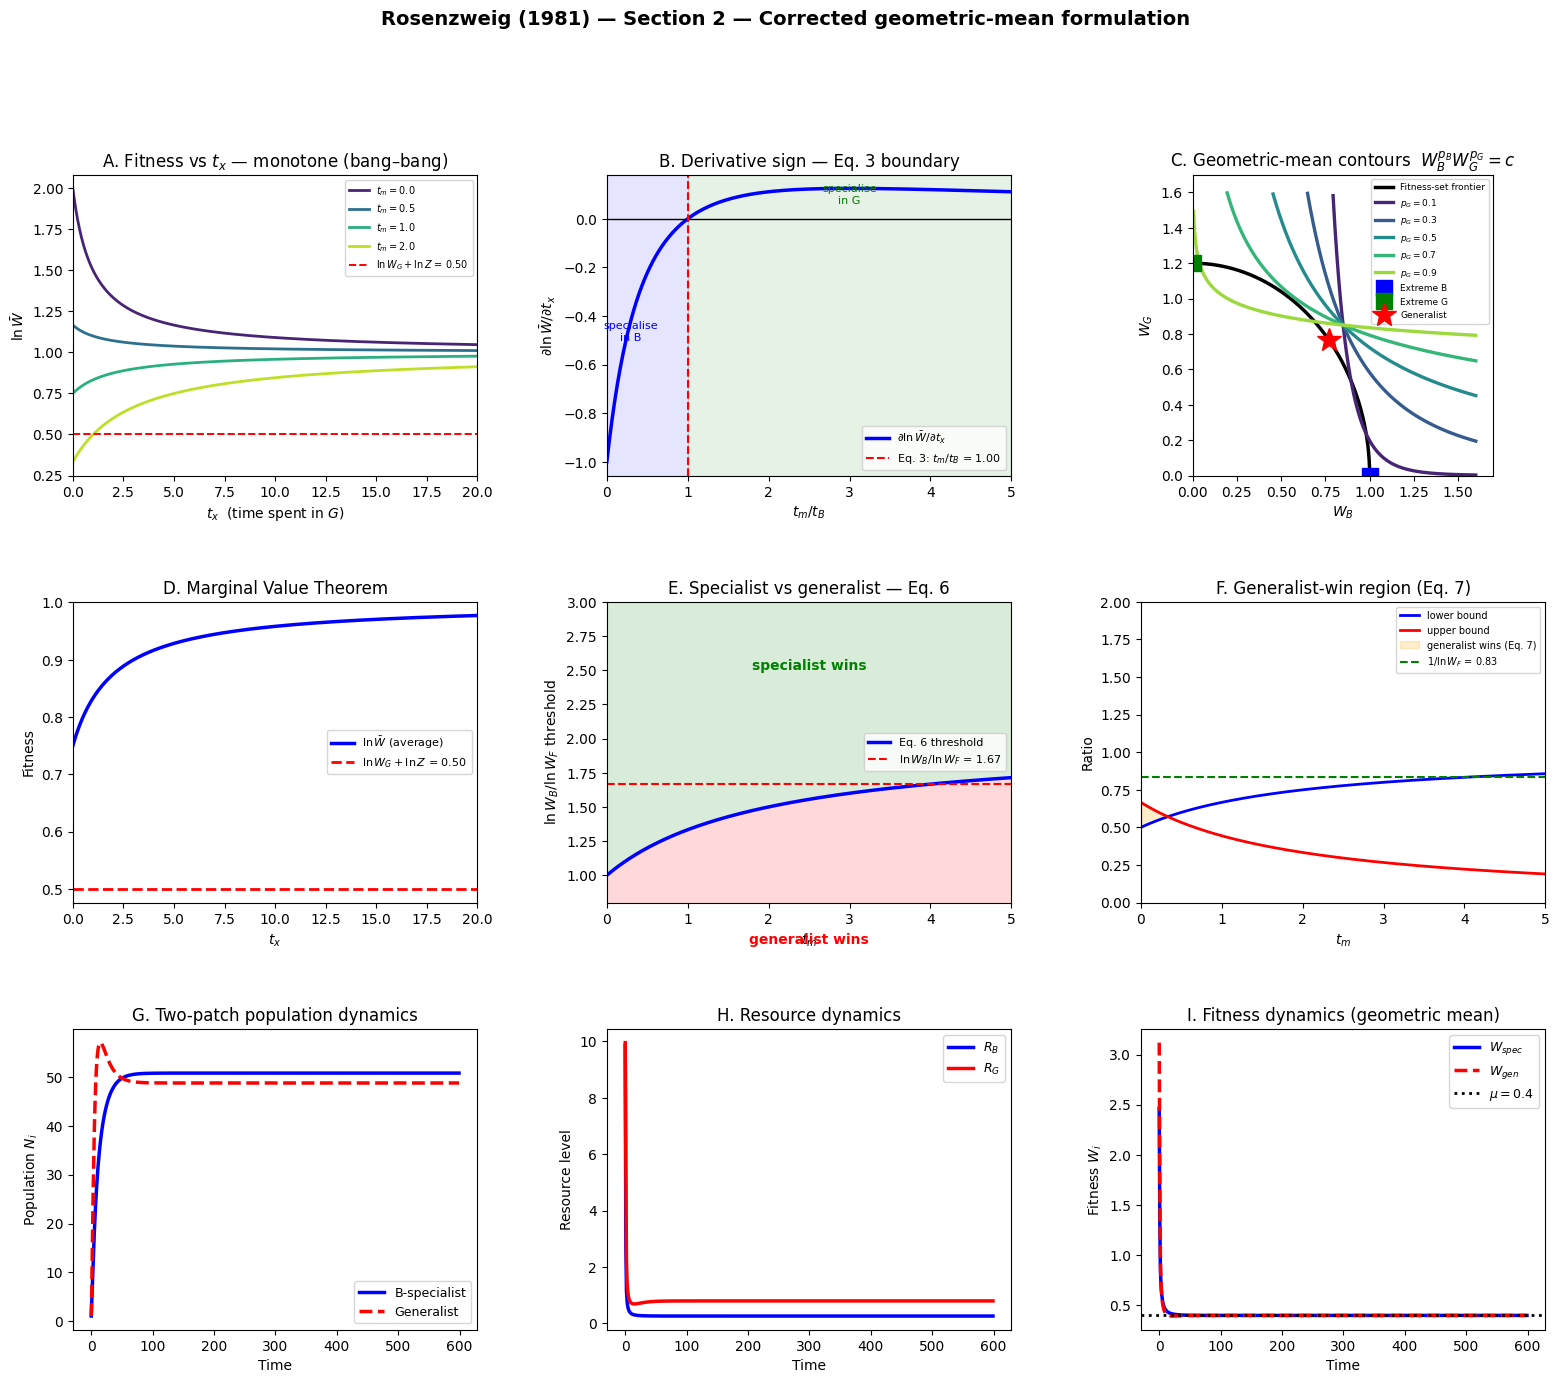

In [5]:
"""
Rosenzweig (1981) — Section 2 (fully rewritten)
Habitat selection with a searching cost.

Key formulas
------------
  Eq. 1a:  ln W_bar = (t_B ln W_B + t_x ln W_G + t_m ln Z) / D
  Eq. 1a': W_bar   = W_B^{u_B} * W_G^{u_G} * Z^{u_m}
  Eq. 3 :  ln W_B > ln W_G (1 + t_m/t_B)
  Eq. 6 :  ln W_B/ln W_F > 1 + t_m/(2 t_B + t_m)

Dynamics
--------
  Resource:    dR_B/dt = r_B (K_B - R_B) - sum_i N_i u_B c_B R_B
               dR_G/dt = r_G (K_G - R_G) - sum_i N_i u_G c_G R_G
  Fitness:     W_i = (c_B R_B)^{u_B} (c_G R_G)^{u_G} Z^{u_m}
  Population:  dN_i/dt = N_i (W_i - mu)

Panels
------
  A. ln W_bar vs t_x for several t_m       (bang-bang)
  B. d ln W_bar / d t_x vs t_m/t_B          (Eq. 3 boundary)
  C. Geometric-mean fitness contours
  D. Marginal Value Theorem
  E. Eq. 6 specialist-vs-generalist
  F. Eq. 7 generalist-win region
  G. Two-patch population dynamics
  H. Resource dynamics
  I. Fitness dynamics and mu
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ============================================================
# PARAMETERS
# ============================================================
t_B   = 1.0          # foraging time per B-patch set
ln_WB = 2.0          # ln W_B (gross, analytical panels)
ln_WG = 1.0          # ln W_G (gross, analytical panels)
ln_Z  = -0.5         # ln Z  (searching cost rate)
Z_val = np.exp(ln_Z) # Z itself (positive, < 1)
W_F   = 1.2          # ln W_F (generalist fitness for Eq. 6/7)

# Resource-dynamics parameters
K_B, K_G = 10.0, 10.0
r_B, r_G = 1.0,  1.0
a_B, a_G = 1.0,  1.0
mu       = 0.4

# ============================================================
# CORE FUNCTIONS (Eq. 1a and Eq. 3)
# ============================================================
def ln_W_bar(t_x, t_m, lnW_B=ln_WB, lnW_G=ln_WG, lnZ=ln_Z, tB=t_B):
    """Eq. 1a — average log-fitness."""
    D = tB + t_x + t_m
    return (tB*lnW_B + t_x*lnW_G + t_m*lnZ) / D

def dlnW_dtx(t_x, t_m, lnW_B=ln_WB, lnW_G=ln_WG, tB=t_B):
    """Derivative of ln W_bar w.r.t. t_x."""
    D = tB + t_x + t_m
    return (lnW_G*(tB + t_m) - tB*lnW_B) / D**2

def criterion_3(t_m, lnW_B=ln_WB, lnW_G=ln_WG, tB=t_B):
    """Eq. 3 boundary:  ln W_B = ln W_G (1 + t_m/t_B)."""
    return lnW_G * (1.0 + t_m / tB)

def specialist_lnW(t_m, lnW_B=ln_WB, lnZ=ln_Z, tB=t_B):
    """Specialist (t_x = 0)."""
    return tB*lnW_B / (tB + t_m) + lnZ

def generalist_lnW(t_m, lnW_F=W_F, lnZ=ln_Z, tB=t_B):
    """Generalist (t_x = t_B)."""
    return 2.0*tB*lnW_F / (2.0*tB + t_m) + lnZ

def criterion_6(t_m, tB=t_B):
    """Eq. 6 threshold."""
    return 1.0 + t_m / (2.0*tB + t_m)

# ============================================================
# GEOMETRIC-MEAN CONTOUR HELPER
# ============================================================
def contour_geom(p_G, c, W_B_arr, Z_val=Z_val, p_m=0.0):
    """
    Contour of  W_B^{1-p_G-p_m} W_G^{p_G} Z^{p_m} = c
    =>  W_G = ( c / (Z^{p_m} W_B^{1-p_G-p_m}) )^{1/p_G}.
    """
    p_B = 1.0 - p_G - p_m
    eps = 1e-12
    W_B_safe = np.clip(W_B_arr, eps, None)
    if p_G <= 0.0:
        return np.full_like(W_B_safe, np.nan)
    numer = c / (Z_val**p_m * W_B_safe**p_B)
    return numer**(1.0 / p_G)

# ============================================================
# FIGURE
# ============================================================
fig = plt.figure(figsize=(19, 15))
gs  = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

t_x_arr = np.linspace(0.0, 20.0, 600)
t_m_arr = np.linspace(0.0, 5.0, 600)

# ============================================================
# Panel A — ln W_bar vs t_x
# ============================================================
ax_A = fig.add_subplot(gs[0, 0])
t_m_vals = [0.0, 0.5, 1.0, 2.0]
colors_A = plt.cm.viridis(np.linspace(0.10, 0.90, len(t_m_vals)))
for t_m, c in zip(t_m_vals, colors_A):
    ax_A.plot(t_x_arr, ln_W_bar(t_x_arr, t_m), color=c, lw=2.0,
              label=f'$t_m = {t_m:.1f}$')
ax_A.axhline(ln_WG + ln_Z, color='red', ls='--', lw=1.4,
             label=f'$\\ln W_G + \\ln Z$ = {ln_WG + ln_Z:.2f}')
ax_A.set_xlabel('$t_x$  (time spent in $G$)')
ax_A.set_ylabel('$\\ln \\bar W$')
ax_A.set_title('A. Fitness vs $t_x$ — monotone (bang–bang)')
ax_A.legend(fontsize=7)
ax_A.set_xlim(0.0, 20.0)

# ============================================================
# Panel B — Derivative sign
# ============================================================
ax_B = fig.add_subplot(gs[0, 1])
ratio = t_m_arr / t_B
dln = dlnW_dtx(0.0, t_m_arr)
ax_B.plot(ratio, dln, 'b-', lw=2.5, label='$\\partial\\ln\\bar W / \\partial t_x$')
ax_B.axhline(0.0, color='k', lw=1.0)
ax_B.axvline(ln_WB/ln_WG - 1.0, color='red', ls='--', lw=1.5,
             label=f'Eq. 3: $t_m/t_B$ = {ln_WB/ln_WG - 1:.2f}')
ax_B.axvspan(0.0, ln_WB/ln_WG - 1.0, alpha=0.10, color='blue')
ax_B.axvspan(ln_WB/ln_WG - 1.0, ratio.max(), alpha=0.10, color='green')
ax_B.text(0.3, dln.min()*0.5, 'specialise\nin B', ha='center',
          fontsize=8, color='blue')
ax_B.text(3.0, dln.max()*0.5, 'specialise\nin G', ha='center',
          fontsize=8, color='green')
ax_B.set_xlabel('$t_m / t_B$')
ax_B.set_ylabel('$\\partial\\ln\\bar W / \\partial t_x$')
ax_B.set_title('B. Derivative sign — Eq. 3 boundary')
ax_B.legend(fontsize=8)
ax_B.set_xlim(0.0, ratio.max())

# ============================================================
# Panel C — Geometric-mean fitness contours
# ============================================================
ax_C = fig.add_subplot(gs[0, 2])
W_B_lin = np.linspace(1e-6, 1.6, 600)

# Fitness-set frontier (Section 1 ellipse)
theta_C = np.linspace(0, np.pi/2, 400)
W_B0_lim, W_G0_lim = 1.0, 1.2
ax_C.plot(W_B0_lim*np.cos(theta_C), W_G0_lim*np.sin(theta_C),
          'k-', lw=2.5, label='Fitness-set frontier')

# Geometric-mean contours  W_B^{p_B} W_G^{p_G} = c   (p_B + p_G = 1)
p_G_list = [0.10, 0.30, 0.50, 0.70, 0.90]
colors_C = plt.cm.viridis(np.linspace(0.10, 0.85, len(p_G_list)))
for p_G, col in zip(p_G_list, colors_C):
    c_ref = 0.85
    W_G_c = contour_geom(p_G, c_ref, W_B_lin, Z_val=1.0, p_m=0.0)
    mask = (W_G_c <= 1.6) & (W_G_c >= 0.0)
    ax_C.plot(W_B_lin[mask], W_G_c[mask], '-', color=col, lw=2.4,
              label=f'$p_G = {p_G:.1f}$')

# Landmarks
ax_C.plot(W_B0_lim, 0.0, 'bs', ms=11, label='Extreme B')
ax_C.plot(0.0, W_G0_lim, 'gs', ms=11, label='Extreme G')
ax_C.plot(0.768, 0.768, 'r*', ms=18, label='Generalist')

ax_C.set_xlabel('$W_B$')
ax_C.set_ylabel('$W_G$')
ax_C.set_title('C. Geometric-mean contours  $W_B^{p_B} W_G^{p_G} = c$')
ax_C.legend(fontsize=6.5, loc='upper right')
ax_C.set_xlim(0.0, 1.7)
ax_C.set_ylim(0.0, 1.7)
ax_C.set_aspect('equal')

# ============================================================
# Panel D — Marginal Value Theorem
# ============================================================
ax_D = fig.add_subplot(gs[1, 0])
t_m_D = 1.0
lnW_D = ln_W_bar(t_x_arr, t_m_D)
ax_D.plot(t_x_arr, lnW_D, 'b-', lw=2.5, label='$\\ln\\bar W$ (average)')
ax_D.axhline(ln_WG + ln_Z, color='red', ls='--', lw=2.0,
             label=f'$\\ln W_G + \\ln Z$ = {ln_WG + ln_Z:.2f}')
cross = np.where(np.diff(np.sign(lnW_D - (ln_WG + ln_Z))))[0]
for idx in cross:
    ax_D.plot(t_x_arr[idx], lnW_D[idx], 'ro', ms=10, zorder=5)
ax_D.set_xlabel('$t_x$')
ax_D.set_ylabel('Fitness')
ax_D.set_title('D. Marginal Value Theorem')
ax_D.legend(fontsize=8)
ax_D.set_xlim(0.0, 20.0)

# ============================================================
# Panel E — Specialist vs generalist (Eq. 6)
# ============================================================
ax_E = fig.add_subplot(gs[1, 1])
t_m_E = np.linspace(0.0, 5.0, 600)
threshold_E = criterion_6(t_m_E)
ax_E.plot(t_m_E, threshold_E, 'b-', lw=2.5, label='Eq. 6 threshold')
ax_E.axhline(ln_WB / W_F, color='red', ls='--', lw=1.5,
             label=f'$\\ln W_B / \\ln W_F$ = {ln_WB/W_F:.2f}')
ax_E.fill_between(t_m_E, threshold_E, 3.0, alpha=0.15, color='green')
ax_E.fill_between(t_m_E, 0.0, threshold_E, alpha=0.15, color='red')
ax_E.text(2.5, 2.5, 'specialist wins', ha='center',
          fontsize=10, color='green', fontweight='bold')
ax_E.text(2.5, 0.5, 'generalist wins', ha='center',
          fontsize=10, color='red', fontweight='bold')
ax_E.set_xlabel('$t_m$')
ax_E.set_ylabel('$\\ln W_B / \\ln W_F$ threshold')
ax_E.set_title('E. Specialist vs generalist — Eq. 6')
ax_E.legend(fontsize=8, loc='center right')
ax_E.set_xlim(0.0, 5.0)
ax_E.set_ylim(0.8, 3.0)

# ============================================================
# Panel F — Generalist-win region (Eq. 7)
# ============================================================
ax_F = fig.add_subplot(gs[1, 2])
t_m_F = np.linspace(0.01, 5.0, 600)
W_C   = 1.5
lower = (2.0*t_B + 2.0*t_m_F) / (ln_WB*(2.0*t_B + t_m_F))
upper = (2.0*t_B) / (W_C*(2.0*t_B + t_m_F))
ax_F.plot(t_m_F, lower, 'b-', lw=2.0, label='lower bound')
ax_F.plot(t_m_F, upper, 'r-', lw=2.0, label='upper bound')
ax_F.fill_between(t_m_F, lower, upper, where=(lower < upper),
                  alpha=0.20, color='orange',
                  label='generalist wins (Eq. 7)')
ax_F.axhline(1.0 / W_F, color='green', ls='--', lw=1.5,
             label=f'$1/\\ln W_F$ = {1.0/W_F:.2f}')
ax_F.set_xlabel('$t_m$')
ax_F.set_ylabel('Ratio')
ax_F.set_title('F. Generalist-win region (Eq. 7)')
ax_F.legend(fontsize=7)
ax_F.set_xlim(0.0, 5.0)
ax_F.set_ylim(0.0, 2.0)

# ============================================================
# DYNAMICS — Corrected two-patch model
# ============================================================
# Two strategies
# B-specialist: t_x = 0
D_spec   = t_B + 0.0 + 1.0    # t_m fixed at 1.0 for the simulation
u_B_spec = t_B / D_spec
u_G_spec = 0.0
u_m_spec = 1.0 / D_spec

# Generalist: t_x = t_B
t_m_sim  = 1.0
D_gen    = 2.0*t_B + t_m_sim
u_B_gen  = t_B / D_gen
u_G_gen  = t_B / D_gen
u_m_gen  = t_m_sim / D_gen

# Capture efficiencies
c_B_spec, c_G_spec = 1.0, 0.0
c_B_gen,  c_G_gen  = 1.0/np.sqrt(2), 1.0/np.sqrt(2)

def W_i(c_B, c_G, R_B, R_G, u_B, u_G, u_m):
    """
    Geometric-mean fitness:
        W = (c_B R_B)^{u_B} * (c_G R_G)^{u_G} * Z^{u_m}
    computed in log space; terms with u = 0 are silently skipped.
    """
    lnW = 0.0
    if u_B > 0.0:
        lnW += u_B * np.log(max(c_B * R_B, 1e-300))
    if u_G > 0.0:
        lnW += u_G * np.log(max(c_G * R_G, 1e-300))
    if u_m > 0.0:
        lnW += u_m * np.log(Z_val)
    return np.exp(lnW)

def simulate(T=600.0, dt=0.02,
             N_spec0=1.0, N_gen0=1.0,
             R_B0=None, R_G0=None):
    R_B = K_B if R_B0 is None else R_B0
    R_G = K_G if R_G0 is None else R_G0
    N_spec = N_spec0
    N_gen  = N_gen0

    n_steps = int(T/dt)
    rec = {
        't':  [], 'N_spec': [], 'N_gen': [],
        'R_B': [], 'R_G': [],
        'W_spec': [], 'W_gen': []
    }

    for step in range(n_steps):
        # Fitnesses (geometric mean)
        W_spec = W_i(c_B_spec, c_G_spec, R_B, R_G,
                     u_B_spec, u_G_spec, u_m_spec)
        W_gen  = W_i(c_B_gen,  c_G_gen,  R_B, R_G,
                     u_B_gen,  u_G_gen,  u_m_gen)

        # Consumption of each patch
        cons_B = a_B * (N_spec*u_B_spec*c_B_spec
                        + N_gen *u_B_gen *c_B_gen) * R_B
        cons_G = a_G * (N_spec*u_G_spec*c_G_spec
                        + N_gen *u_G_gen *c_G_gen) * R_G

        # Resource dynamics
        dR_B = r_B*(K_B - R_B) - cons_B
        dR_G = r_G*(K_G - R_G) - cons_G
        R_B = max(R_B + dR_B*dt, 1e-12)
        R_G = max(R_G + dR_G*dt, 1e-12)

        # Population dynamics on W_i (NOT on ln W_i)
        N_spec = max(N_spec + N_spec*(W_spec - mu)*dt, 0.0)
        N_gen  = max(N_gen  + N_gen *(W_gen  - mu)*dt, 0.0)

        if step % 50 == 0:
            rec['t'].append(step*dt)
            rec['N_spec'].append(N_spec)
            rec['N_gen'].append(N_gen)
            rec['R_B'].append(R_B)
            rec['R_G'].append(R_G)
            rec['W_spec'].append(W_spec)
            rec['W_gen'].append(W_gen)

    return {k: np.array(v) for k, v in rec.items()}

sim = simulate()

# ============================================================
# Panel G — Populations
# ============================================================
ax_G = fig.add_subplot(gs[2, 0])
ax_G.plot(sim['t'], sim['N_spec'], 'b-',  lw=2.5, label='B-specialist')
ax_G.plot(sim['t'], sim['N_gen'],  'r--', lw=2.5, label='Generalist')
ax_G.set_xlabel('Time')
ax_G.set_ylabel('Population $N_i$')
ax_G.set_title('G. Two-patch population dynamics')
ax_G.legend(fontsize=9)

# ============================================================
# Panel H — Resources
# ============================================================
ax_H = fig.add_subplot(gs[2, 1])
ax_H.plot(sim['t'], sim['R_B'], 'b-', lw=2.5, label='$R_B$')
ax_H.plot(sim['t'], sim['R_G'], 'r-', lw=2.5, label='$R_G$')
ax_H.set_xlabel('Time')
ax_H.set_ylabel('Resource level')
ax_H.set_title('H. Resource dynamics')
ax_H.legend(fontsize=9)

# ============================================================
# Panel I — Fitnesses and mu
# ============================================================
ax_I = fig.add_subplot(gs[2, 2])
ax_I.plot(sim['t'], sim['W_spec'], 'b-',  lw=2.5, label='$W_{spec}$')
ax_I.plot(sim['t'], sim['W_gen'],  'r--', lw=2.5, label='$W_{gen}$')
ax_I.axhline(mu, color='k', ls=':', lw=2.0, label=f'$\\mu = {mu}$')
ax_I.set_xlabel('Time')
ax_I.set_ylabel('Fitness $W_i$')
ax_I.set_title('I. Fitness dynamics (geometric mean)')
ax_I.legend(fontsize=9)

plt.suptitle('Rosenzweig (1981) — Section 2 — Corrected geometric-mean formulation',
             fontsize=14, fontweight='bold', y=0.99)

plt.savefig('rosenzweig_section2_final.png', dpi=150, bbox_inches='tight')
plt.show()

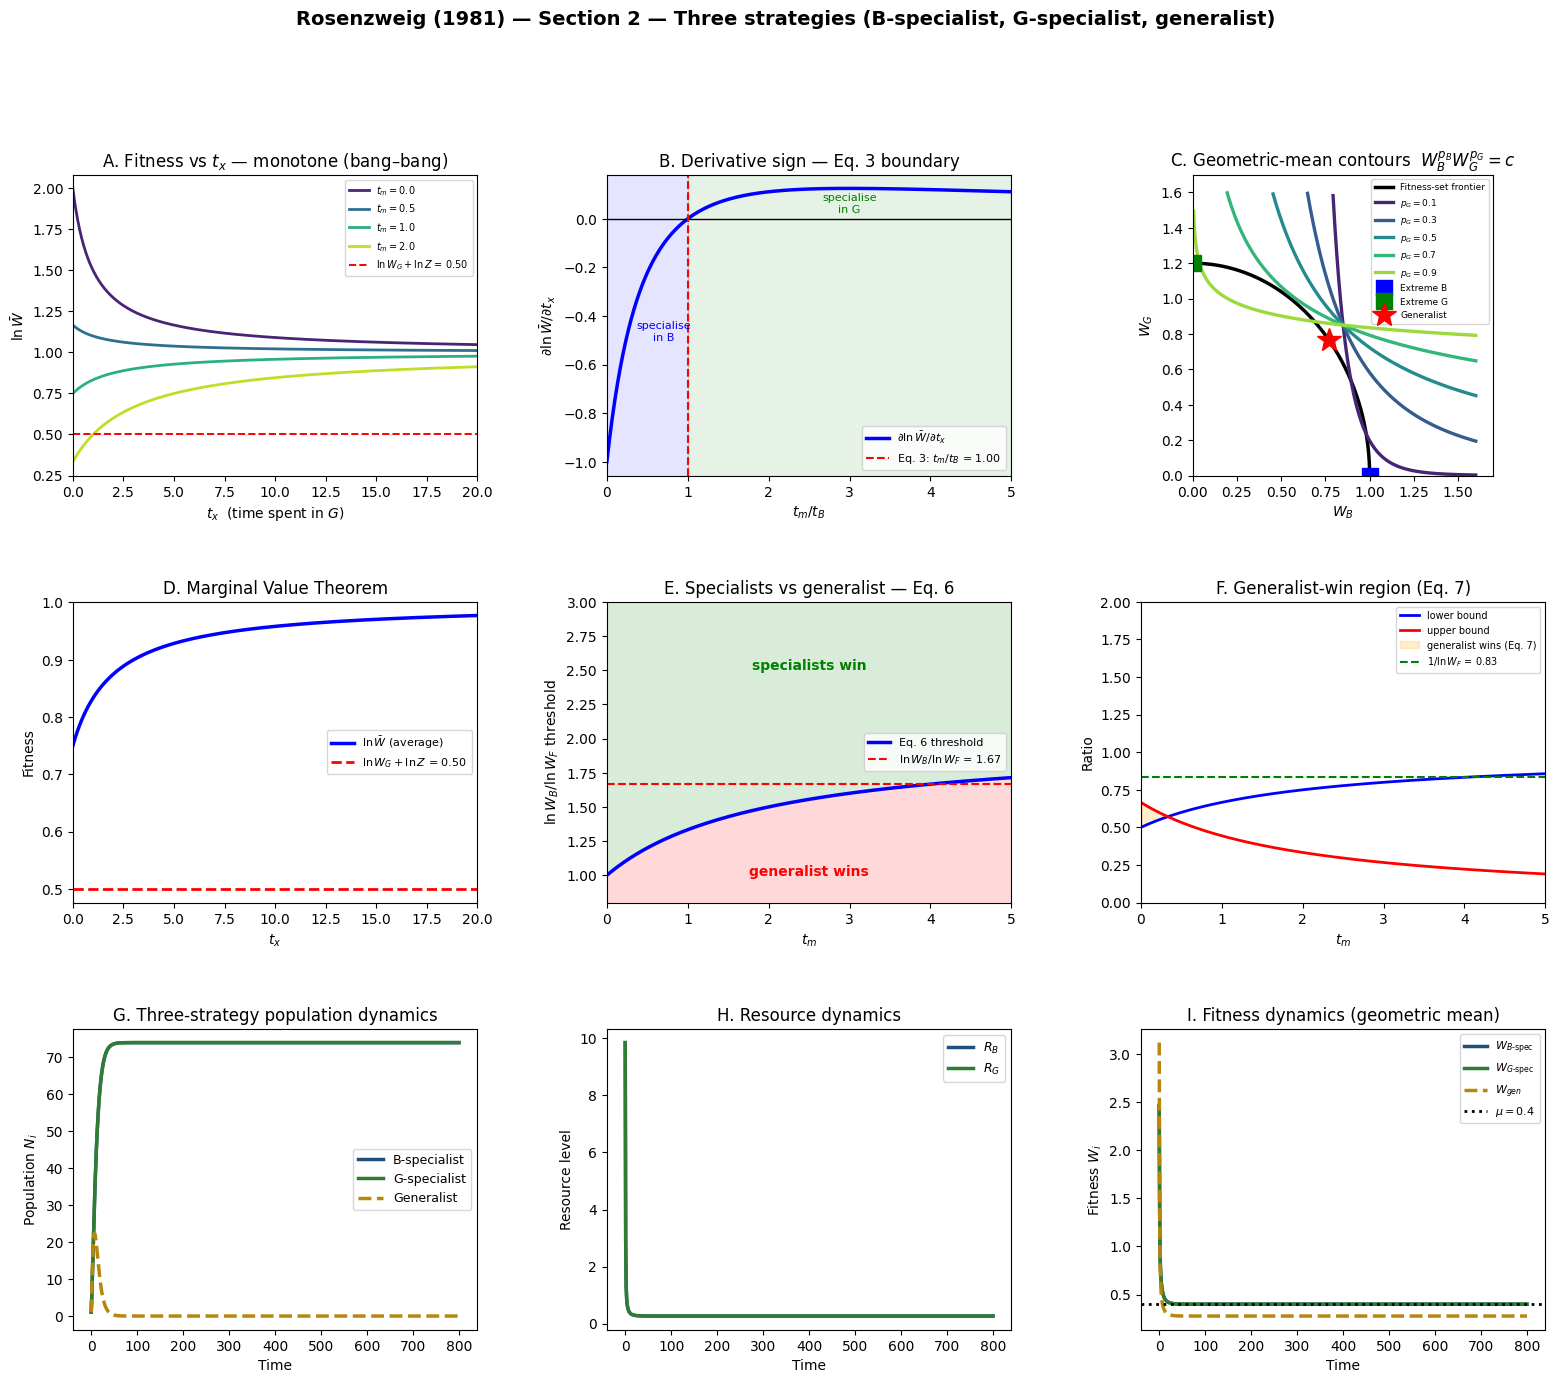

In [13]:
"""
Rosenzweig (1981) — Section 2 (final version)
Three strategies: B-specialist, G-specialist, Generalist.

Key formulas
------------
  Eq. 1a:  ln W_bar = (t_B ln W_B + t_x ln W_G + t_m ln Z) / D
  Eq. 1a': W_bar   = W_B^{u_B} * W_G^{u_G} * Z^{u_m}
  Eq. 3 :  ln W_B > ln W_G (1 + t_m/t_B)
  Eq. 6 :  ln W_B/ln W_F > 1 + t_m/(2 t_B + t_m)

Dynamics
--------
  Resource:    dR_B/dt = r_B (K_B - R_B) - sum_i N_i u_B c_B R_B
               dR_G/dt = r_G (K_G - R_G) - sum_i N_i u_G c_G R_G
  Fitness:     W_i = (c_B R_B)^{u_B} (c_G R_G)^{u_G} Z^{u_m}
  Population:  dN_i/dt = N_i (W_i - mu)

Panels
------
  A. ln W_bar vs t_x for several t_m       (bang-bang)
  B. d ln W_bar / d t_x vs t_m/t_B          (Eq. 3 boundary)
  C. Geometric-mean fitness contours
  D. Marginal Value Theorem
  E. Eq. 6 specialist-vs-generalist
  F. Eq. 7 generalist-win region
  G. Two-patch population dynamics (3 strategies)
  H. Resource dynamics
  I. Fitness dynamics and mu
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ============================================================
# PARAMETERS
# ============================================================
t_B     = 1.0          # foraging time (per patch set) — same for all strategies
t_m     = 1.0          # searching time between patch sets
ln_WB   = 2.0          # ln W_B (analytical panels)
ln_WG   = 1.0          # ln W_G (analytical panels)
ln_Z    = -0.5         # ln Z  (searching cost rate)
Z_val   = np.exp(ln_Z) # Z itself (positive, < 1)
W_F     = 1.2          # ln W_F (generalist fitness for Eq. 6/7)
mu      = 0.4          # mortality / maintenance

# Resource dynamics
K_B, K_G = 10.0, 10.0
r_B, r_G = 1.0,  1.0
a_B, a_G = 1.0,  1.0

# ============================================================
# CORE FUNCTIONS (Eq. 1a and Eq. 3)
# ============================================================
def ln_W_bar(t_x, t_m_, lnW_B=ln_WB, lnW_G=ln_WG, lnZ=ln_Z, tB=t_B):
    """Eq. 1a — average log-fitness."""
    D = tB + t_x + t_m_
    return (tB*lnW_B + t_x*lnW_G + t_m_*lnZ) / D

def dlnW_dtx(t_x, t_m_, lnW_B=ln_WB, lnW_G=ln_WG, tB=t_B):
    """Derivative of ln W_bar w.r.t. t_x."""
    D = tB + t_x + t_m_
    return (lnW_G*(tB + t_m_) - tB*lnW_B) / D**2

def criterion_3(t_m_, lnW_B=ln_WB, lnW_G=ln_WG, tB=t_B):
    """Eq. 3 boundary:  ln W_B = ln W_G (1 + t_m/t_B)."""
    return lnW_G * (1.0 + t_m_ / tB)

def criterion_6(t_m_, tB=t_B):
    """Eq. 6 threshold."""
    return 1.0 + t_m_ / (2.0*tB + t_m_)

def specialist_lnW(t_m_, lnW_spec, lnZ=ln_Z, tB=t_B):
    """Specialist that uses one patch with foraging time t_B."""
    return tB * lnW_spec / (tB + t_m_) + lnZ

def generalist_lnW(t_m_, lnW_F=W_F, lnZ=ln_Z, tB=t_B):
    """Generalist: t_B = t_x."""
    return 2.0*tB*lnW_F / (2.0*tB + t_m_) + lnZ

# ============================================================
# GEOMETRIC-MEAN CONTOUR HELPER
# ============================================================
def contour_geom(p_G, c, W_B_arr, Z_val=Z_val, p_m=0.0):
    """
    Contour of  W_B^{1-p_G-p_m} W_G^{p_G} Z^{p_m} = c
    =>  W_G = ( c / (Z^{p_m} W_B^{1-p_G-p_m}) )^{1/p_G}.
    """
    p_B = 1.0 - p_G - p_m
    eps = 1e-12
    W_B_safe = np.clip(W_B_arr, eps, None)
    if p_G <= 0.0:
        return np.full_like(W_B_safe, np.nan)
    numer = c / (Z_val**p_m * W_B_safe**p_B)
    return numer**(1.0 / p_G)

# ============================================================
# FIGURE
# ============================================================
fig = plt.figure(figsize=(19, 15))
gs  = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

t_x_arr = np.linspace(0.0, 20.0, 600)
t_m_arr = np.linspace(0.0, 5.0, 600)

# ============================================================
# Panel A — ln W_bar vs t_x
# ============================================================
ax_A = fig.add_subplot(gs[0, 0])
t_m_vals = [0.0, 0.5, 1.0, 2.0]
colors_A = plt.cm.viridis(np.linspace(0.10, 0.90, len(t_m_vals)))
for tm, c in zip(t_m_vals, colors_A):
    ax_A.plot(t_x_arr, ln_W_bar(t_x_arr, tm), color=c, lw=2.0,
              label=f'$t_m = {tm:.1f}$')
ax_A.axhline(ln_WG + ln_Z, color='red', ls='--', lw=1.4,
             label=f'$\\ln W_G + \\ln Z$ = {ln_WG + ln_Z:.2f}')
ax_A.set_xlabel('$t_x$  (time spent in $G$)')
ax_A.set_ylabel('$\\ln \\bar W$')
ax_A.set_title('A. Fitness vs $t_x$ — monotone (bang–bang)')
ax_A.legend(fontsize=7)
ax_A.set_xlim(0.0, 20.0)

# ============================================================
# Panel B — Derivative sign
# ============================================================
ax_B = fig.add_subplot(gs[0, 1])
ratio = t_m_arr / t_B
dln = dlnW_dtx(0.0, t_m_arr)
ax_B.plot(ratio, dln, 'b-', lw=2.5, label='$\\partial\\ln\\bar W / \\partial t_x$')
ax_B.axhline(0.0, color='k', lw=1.0)
ax_B.axvline(ln_WB/ln_WG - 1.0, color='red', ls='--', lw=1.5,
             label=f'Eq. 3: $t_m/t_B$ = {ln_WB/ln_WG - 1:.2f}')
ax_B.axvspan(0.0, ln_WB/ln_WG - 1.0, alpha=0.10, color='blue')
ax_B.axvspan(ln_WB/ln_WG - 1.0, ratio.max(), alpha=0.10, color='green')
ax_B.text(0.7, dln.min()*0.5, 'specialise\nin B', ha='center',
          fontsize=8, color='blue')
ax_B.text(3.0, dln.max()*0.2, 'specialise\nin G', ha='center',
          fontsize=8, color='green')
ax_B.set_xlabel('$t_m / t_B$')
ax_B.set_ylabel('$\\partial\\ln\\bar W / \\partial t_x$')
ax_B.set_title('B. Derivative sign — Eq. 3 boundary')
ax_B.legend(fontsize=8)
ax_B.set_xlim(0.0, ratio.max())

# ============================================================
# Panel C — Geometric-mean fitness contours
# ============================================================
ax_C = fig.add_subplot(gs[0, 2])
W_B_lin = np.linspace(1e-6, 1.6, 600)

theta_C = np.linspace(0, np.pi/2, 400)
W_B0_lim, W_G0_lim = 1.0, 1.2
ax_C.plot(W_B0_lim*np.cos(theta_C), W_G0_lim*np.sin(theta_C),
          'k-', lw=2.5, label='Fitness-set frontier')

p_G_list = [0.10, 0.30, 0.50, 0.70, 0.90]
colors_C = plt.cm.viridis(np.linspace(0.10, 0.85, len(p_G_list)))
for p_G, col in zip(p_G_list, colors_C):
    c_ref = 0.85
    W_G_c = contour_geom(p_G, c_ref, W_B_lin, Z_val=1.0, p_m=0.0)
    mask = (W_G_c <= 1.6) & (W_G_c >= 0.0)
    ax_C.plot(W_B_lin[mask], W_G_c[mask], '-', color=col, lw=2.4,
              label=f'$p_G = {p_G:.1f}$')

ax_C.plot(W_B0_lim, 0.0, 'bs', ms=11, label='Extreme B')
ax_C.plot(0.0, W_G0_lim, 'gs', ms=11, label='Extreme G')
ax_C.plot(0.768, 0.768, 'r*', ms=18, label='Generalist')

ax_C.set_xlabel('$W_B$')
ax_C.set_ylabel('$W_G$')
ax_C.set_title('C. Geometric-mean contours  $W_B^{p_B} W_G^{p_G} = c$')
ax_C.legend(fontsize=6.5, loc='upper right')
ax_C.set_xlim(0.0, 1.7)
ax_C.set_ylim(0.0, 1.7)
ax_C.set_aspect('equal')

# ============================================================
# Panel D — Marginal Value Theorem
# ============================================================
ax_D = fig.add_subplot(gs[1, 0])
t_m_D = 1.0
lnW_D = ln_W_bar(t_x_arr, t_m_D)
ax_D.plot(t_x_arr, lnW_D, 'b-', lw=2.5, label='$\\ln\\bar W$ (average)')
ax_D.axhline(ln_WG + ln_Z, color='red', ls='--', lw=2.0,
             label=f'$\\ln W_G + \\ln Z$ = {ln_WG + ln_Z:.2f}')
cross = np.where(np.diff(np.sign(lnW_D - (ln_WG + ln_Z))))[0]
for idx in cross:
    ax_D.plot(t_x_arr[idx], lnW_D[idx], 'ro', ms=10, zorder=5)
ax_D.set_xlabel('$t_x$')
ax_D.set_ylabel('Fitness')
ax_D.set_title('D. Marginal Value Theorem')
ax_D.legend(fontsize=8)
ax_D.set_xlim(0.0, 20.0)

# ============================================================
# Panel E — Specialist vs generalist (Eq. 6)
# ============================================================
ax_E = fig.add_subplot(gs[1, 1])
t_m_E = np.linspace(0.0, 5.0, 600)
threshold_E = criterion_6(t_m_E)
ax_E.plot(t_m_E, threshold_E, 'b-', lw=2.5, label='Eq. 6 threshold')
ax_E.axhline(ln_WB / W_F, color='red', ls='--', lw=1.5,
             label=f'$\\ln W_B / \\ln W_F$ = {ln_WB/W_F:.2f}')
ax_E.fill_between(t_m_E, threshold_E, 3.0, alpha=0.15, color='green')
ax_E.fill_between(t_m_E, 0.0, threshold_E, alpha=0.15, color='red')
ax_E.text(2.5, 2.5, 'specialists win', ha='center',
          fontsize=10, color='green', fontweight='bold')
ax_E.text(2.5, 1.0, 'generalist wins', ha='center',
          fontsize=10, color='red', fontweight='bold')
ax_E.set_xlabel('$t_m$')
ax_E.set_ylabel('$\\ln W_B / \\ln W_F$ threshold')
ax_E.set_title('E. Specialists vs generalist — Eq. 6')
ax_E.legend(fontsize=8, loc='center right')
ax_E.set_xlim(0.0, 5.0)
ax_E.set_ylim(0.8, 3.0)

# ============================================================
# Panel F — Generalist-win region (Eq. 7)
# ============================================================
ax_F = fig.add_subplot(gs[1, 2])
t_m_F = np.linspace(0.01, 5.0, 600)
W_C   = 1.5
lower = (2.0*t_B + 2.0*t_m_F) / (ln_WB*(2.0*t_B + t_m_F))
upper = (2.0*t_B) / (W_C*(2.0*t_B + t_m_F))
ax_F.plot(t_m_F, lower, 'b-', lw=2.0, label='lower bound')
ax_F.plot(t_m_F, upper, 'r-', lw=2.0, label='upper bound')
ax_F.fill_between(t_m_F, lower, upper, where=(lower < upper),
                  alpha=0.20, color='orange',
                  label='generalist wins (Eq. 7)')
ax_F.axhline(1.0 / W_F, color='green', ls='--', lw=1.5,
             label=f'$1/\\ln W_F$ = {1.0/W_F:.2f}')
ax_F.set_xlabel('$t_m$')
ax_F.set_ylabel('Ratio')
ax_F.set_title('F. Generalist-win region (Eq. 7)')
ax_F.legend(fontsize=7)
ax_F.set_xlim(0.0, 5.0)
ax_F.set_ylim(0.0, 2.0)

# ============================================================
# DYNAMICS — Three strategies
# ============================================================
#
# Time fractions
# --------------
# B-specialist: forages only in B (t_x = 0)
# G-specialist: forages only in G (t_B = 0 as far as B is concerned)
# Generalist:   forages equally in both (t_x = t_B)
#
# All three pay the same searching cost t_m between foraging bouts.
#
D_spec   = t_B + t_m                       # cycle length for a specialist
u_for_spec = t_B / D_spec                  # foraging fraction
u_m_spec   = t_m / D_spec                  # searching fraction

D_gen    = 2.0*t_B + t_m                   # cycle length for the generalist
u_B_gen  = t_B / D_gen
u_G_gen  = t_B / D_gen
u_m_gen  = t_m / D_gen

# B-specialist:  all foraging time goes to B
u_B_Bspec, u_G_Bspec = u_for_spec, 0.0
# G-specialist:  all foraging time goes to G
u_B_Gspec, u_G_Gspec = 0.0, u_for_spec

# Searching fraction (same for both specialists)
u_m_Bspec = u_m_spec
u_m_Gspec = u_m_spec

# Capture efficiencies
c_B_Bspec, c_G_Bspec = 1.0, 0.0
c_B_Gspec, c_G_Gspec = 0.0, 1.0
c_B_gen,   c_G_gen   = 1.0/np.sqrt(2), 1.0/np.sqrt(2)

def W_geom(c_B, c_G, R_B, R_G, u_B, u_G, u_m):
    """
    Geometric-mean fitness:
        W = (c_B R_B)^{u_B} * (c_G R_G)^{u_G} * Z^{u_m}
    Computed in log space; terms with u = 0 are skipped.
    """
    lnW = 0.0
    if u_B > 0.0:
        lnW += u_B * np.log(max(c_B * R_B, 1e-300))
    if u_G > 0.0:
        lnW += u_G * np.log(max(c_G * R_G, 1e-300))
    if u_m > 0.0:
        lnW += u_m * np.log(Z_val)
    return np.exp(lnW)

def simulate(T=800.0, dt=0.02,
             N_B0=1.0, N_G0=1.0, N_gen0=1.0,
             R_B0=None, R_G0=None):
    R_B = K_B if R_B0 is None else R_B0
    R_G = K_G if R_G0 is None else R_G0
    N_Bspec = N_B0
    N_Gspec = N_G0
    N_gen   = N_gen0

    n_steps = int(T/dt)
    rec = {'t': [], 'N_Bspec': [], 'N_Gspec': [], 'N_gen': [],
           'R_B': [], 'R_G': [],
           'W_Bspec': [], 'W_Gspec': [], 'W_gen': []}

    for step in range(n_steps):
        # Fitnesses (geometric mean)
        W_Bspec = W_geom(c_B_Bspec, c_G_Bspec, R_B, R_G,
                         u_B_Bspec, u_G_Bspec, u_m_Bspec)
        W_Gspec = W_geom(c_B_Gspec, c_G_Gspec, R_B, R_G,
                         u_B_Gspec, u_G_Gspec, u_m_Gspec)
        W_gen   = W_geom(c_B_gen,   c_G_gen,   R_B, R_G,
                         u_B_gen,   u_G_gen,   u_m_gen)

        # Consumption of each patch
        cons_B = a_B * R_B * (
            N_Bspec * u_B_Bspec * c_B_Bspec
            + N_Gspec * u_B_Gspec * c_B_Gspec
            + N_gen   * u_B_gen   * c_B_gen
        )
        cons_G = a_G * R_G * (
            N_Bspec * u_G_Bspec * c_G_Bspec
            + N_Gspec * u_G_Gspec * c_G_Gspec
            + N_gen   * u_G_gen   * c_G_gen
        )

        # Resource dynamics
        dR_B = r_B*(K_B - R_B) - cons_B
        dR_G = r_G*(K_G - R_G) - cons_G
        R_B = max(R_B + dR_B*dt, 1e-12)
        R_G = max(R_G + dR_G*dt, 1e-12)

        # Population dynamics on W_i (NOT ln W_i)
        N_Bspec = max(N_Bspec + N_Bspec*(W_Bspec - mu)*dt, 0.0)
        N_Gspec = max(N_Gspec + N_Gspec*(W_Gspec - mu)*dt, 0.0)
        N_gen   = max(N_gen   + N_gen  *(W_gen   - mu)*dt, 0.0)

        if step % 50 == 0:
            rec['t'].append(step*dt)
            rec['N_Bspec'].append(N_Bspec)
            rec['N_Gspec'].append(N_Gspec)
            rec['N_gen'].append(N_gen)
            rec['R_B'].append(R_B)
            rec['R_G'].append(R_G)
            rec['W_Bspec'].append(W_Bspec)
            rec['W_Gspec'].append(W_Gspec)
            rec['W_gen'].append(W_gen)

    return {k: np.array(v) for k, v in rec.items()}

sim = simulate()

# ============================================================
# Panel G — Populations (three strategies)
# ============================================================
ax_G = fig.add_subplot(gs[2, 0])
ax_G.plot(sim['t'], sim['N_Bspec'], color='#1f4e79', lw=2.5,
          label='B-specialist')
ax_G.plot(sim['t'], sim['N_Gspec'], color='#2e7d32', lw=2.5,
          label='G-specialist')
ax_G.plot(sim['t'], sim['N_gen'],   color='#b8860b', lw=2.5, ls='--',
          label='Generalist')
ax_G.set_xlabel('Time')
ax_G.set_ylabel('Population $N_i$')
ax_G.set_title('G. Three-strategy population dynamics')
ax_G.legend(fontsize=9)

# ============================================================
# Panel H — Resources
# ============================================================
ax_H = fig.add_subplot(gs[2, 1])
ax_H.plot(sim['t'], sim['R_B'], color='#1f4e79', lw=2.5, label='$R_B$')
ax_H.plot(sim['t'], sim['R_G'], color='#2e7d32', lw=2.5, label='$R_G$')
ax_H.set_xlabel('Time')
ax_H.set_ylabel('Resource level')
ax_H.set_title('H. Resource dynamics')
ax_H.legend(fontsize=9)

# ============================================================
# Panel I — Fitnesses and mu
# ============================================================
ax_I = fig.add_subplot(gs[2, 2])
ax_I.plot(sim['t'], sim['W_Bspec'], color='#1f4e79', lw=2.5,
          label='$W_{B\\text{-spec}}$')
ax_I.plot(sim['t'], sim['W_Gspec'], color='#2e7d32', lw=2.5,
          label='$W_{G\\text{-spec}}$')
ax_I.plot(sim['t'], sim['W_gen'],   color='#b8860b', lw=2.5, ls='--',
          label='$W_{gen}$')
ax_I.axhline(mu, color='k', ls=':', lw=2.0, label=f'$\\mu = {mu}$')
ax_I.set_xlabel('Time')
ax_I.set_ylabel('Fitness $W_i$')
ax_I.set_title('I. Fitness dynamics (geometric mean)')
ax_I.legend(fontsize=8)

plt.suptitle('Rosenzweig (1981) — Section 2 — Three strategies '
             '(B-specialist, G-specialist, generalist)',
             fontsize=14, fontweight='bold', y=0.99)

plt.savefig('rosenzweig_section2_three_strategies.png',
            dpi=150, bbox_inches='tight')
plt.show()